#Section 1: Preparing Dataset

##1.1 ChEMBL Data Retrieval for BRD2

In [ ]:
# Step 1: Install the ChEMBL web services client
!pip install chembl_webresource_client tqdm -q

# Step 2: Import required libraries
from chembl_webresource_client.new_client import new_client
import pandas as pd
from tqdm import tqdm

# Step 3: Initialize the ChEMBL API clients
target = new_client.target
activity = new_client.activity
assay = new_client.assay  # Add assay client for confidence scores

# Step 4: Search for BRD2 target (human)
# CHEMBL1293289 is the canonical identifier for human BRD2
BRD2_target = target.filter(target_chembl_id='CHEMBL1293289').only(['target_chembl_id', 'pref_name', 'organism'])
print(f"Target: {BRD2_target[0]['pref_name']} ({BRD2_target[0]['organism']})")

# Step 5: Retrieve all IC50 activities for BRD2
# We filter for standard_type='IC50' to ensure consistent endpoint
activities = activity.filter(
    target_chembl_id= 'CHEMBL1293289',
    standard_type='IC50',
    standard_units='nM',
    standard_relation='='  # Exact measurements only, no inequalities
).only([
    'molecule_chembl_id',
    'canonical_smiles',
    'standard_value',
    'standard_units',
    'standard_type',
    'pchembl_value',
    'assay_chembl_id',
    'assay_description',
    'document_chembl_id'
])

# Step 6: Convert to DataFrame for analysis with progress bar
print("Fetching activities from ChEMBL...")
activities_list = [record for record in tqdm(activities, desc="Downloading activities")]
df_raw = pd.DataFrame(activities_list)
print(f"Retrieved {len(df_raw):,} IC50 measurements for BRD2")

# Step 7: Get unique assay IDs and fetch their confidence scores
unique_assay_ids = df_raw['assay_chembl_id'].unique().tolist()
print(f"\nFetching confidence scores for {len(unique_assay_ids):,} unique assays...")

# Query assays in batches to get confidence scores
assay_data = []
batch_size = 50  # ChEMBL API works well with batches of 50

for i in tqdm(range(0, len(unique_assay_ids), batch_size), desc="Downloading assay info"):
    batch_ids = unique_assay_ids[i:i + batch_size]
    batch_assays = assay.filter(assay_chembl_id__in=batch_ids).only([
        'assay_chembl_id',
        'confidence_score',
        'assay_type'
    ])
    assay_data.extend(list(batch_assays))

df_assays = pd.DataFrame(assay_data)
print(f"Retrieved confidence scores for {len(df_assays):,} assays")

# Step 8: Merge activity data with assay confidence scores
df_raw = df_raw.merge(df_assays, on='assay_chembl_id', how='left')

print(f"\nConfidence score distribution:")
print(df_raw['confidence_score'].value_counts().sort_index(ascending=False))

df_raw.to_csv('DATASET_BRD2_chembl_ic50_raw.csv', index=False)
print(f"\nSaved {len(df_raw):,} records to DATASET_BRD2_chembl_ic50_raw.csv")



Target: Bromodomain-containing protein 2 (Homo sapiens)
Fetching activities from ChEMBL...


Retrieved 1,056 IC50 measurements for BRD2

Fetching confidence scores for 168 unique assays...


Retrieved confidence scores for 168 assays

Confidence score distribution:
confidence_score
9    427
8    629
Name: count, dtype: int64

Saved 1,056 records to DATASET_BRD2_chembl_ic50_raw.csv


##1.2 Bioactivity Data Curation

###1.2.1 Endpoint Standardization

In [ ]:
import numpy as np
import pandas as pd
import io

# Check if df_raw exists; if not, prompt for file upload
try:
    df_raw
except NameError:
    # Try Google Colab upload first, fall back to ipywidgets
    try:
        from google.colab import files
        print("Please upload your dataset file (eg DATASET_BRD2_chembl_ic50_raw.csv):")
        uploaded = files.upload()
        filename = list(uploaded.keys())[0]
    except ImportError:
        # For Jupyter Notebook
        import ipywidgets as widgets
        from IPython.display import display
        import io

        uploader = widgets.FileUpload(accept='.csv,.xlsx,.xls,.tsv', multiple=False)
        print("Please upload your dataset file (eg DATASET_BRD2_chembl_ic50_raw.csv):")
        display(uploader)

        # Wait for upload
        import time
        while not uploader.value:
            time.sleep(0.1)

        filename = list(uploader.value.keys())[0]
        uploaded = {filename: uploader.value[filename]['content']}

    # Read the file based on extension
    if filename.endswith('.csv'):
        df_raw = pd.read_csv(io.BytesIO(uploaded[filename]) if isinstance(uploaded[filename], bytes) else filename)
    elif filename.endswith(('.xlsx', '.xls')):
        df_raw = pd.read_excel(io.BytesIO(uploaded[filename]) if isinstance(uploaded[filename], bytes) else filename)
    elif filename.endswith('.tsv'):
        df_raw = pd.read_csv(io.BytesIO(uploaded[filename]) if isinstance(uploaded[filename], bytes) else filename, sep='\t')
    else:
        # Default to CSV
        df_raw = pd.read_csv(io.BytesIO(uploaded[filename]) if isinstance(uploaded[filename], bytes) else filename)

    print(f"Loaded '{filename}' with {len(df_raw):,} rows and {len(df_raw.columns)} columns")
    print(f"Columns: {list(df_raw.columns)}")

# Initialize a list to track dropped compounds
dropped_records = []

# Step 1: Remove entries with missing activity values
missing_mask = df_raw['standard_value'].isna() | df_raw['canonical_smiles'].isna()
dropped_missing = df_raw[missing_mask].copy()
dropped_missing['drop_reason'] = 'Missing activity value or SMILES'
dropped_records.append(dropped_missing)

df = df_raw.dropna(subset=['standard_value', 'canonical_smiles']).copy()
print(f"After removing missing values: {len(df):,} entries (dropped {len(dropped_missing):,})")

# Step 2: Convert IC50 (nM) to pIC50
df['pIC50'] = 9 - np.log10(df['standard_value'].astype(float))

# Step 3: Apply reasonable activity range filter
too_low_mask = df['pIC50'] < 3
too_high_mask = df['pIC50'] > 12

dropped_too_low = df[too_low_mask].copy()
dropped_too_low['drop_reason'] = 'pIC50 < 3 (IC50 > 1 mM, essentially inactive)'

dropped_too_high = df[too_high_mask].copy()
dropped_too_high['drop_reason'] = 'pIC50 > 12 (IC50 < 1 pM, unrealistically potent)'

dropped_records.append(dropped_too_low)
dropped_records.append(dropped_too_high)

df = df[(df['pIC50'] >= 3) & (df['pIC50'] <= 12)]
print(f"After activity range filter: {len(df):,} entries (dropped {len(dropped_too_low) + len(dropped_too_high):,})")

# Step 4: Examine the pIC50 distribution
print(f"\npIC50 Statistics:")
print(f"  Mean: {df['pIC50'].mean():.2f}")
print(f"  Std:  {df['pIC50'].std():.2f}")
print(f"  Min:  {df['pIC50'].min():.2f}")
print(f"  Max:  {df['pIC50'].max():.2f}")

# Step 5: Compile and export dropped compounds
dropped_df = pd.concat(dropped_records, ignore_index=True)
dropped_df.to_csv('REPORT_BRD2_ic50_affinity_filter_dropped_compounds.csv', index=False)
print(f"\nDropped compounds report saved to 'REPORT_BRD2_ dropped_compounds.csv'")
print(f"Total compounds dropped: {len(dropped_df):,}")


After removing missing values: 1,055 entries (dropped 1)
After activity range filter: 1,054 entries (dropped 1)

pIC50 Statistics:
  Mean: 6.71
  Std:  1.01
  Min:  3.59
  Max:  10.00

Dropped compounds report saved to 'REPORT_BRD2_ dropped_compounds.csv'
Total compounds dropped: 2


###1.2.2 Duplicate Handling

In [ ]:
# Step 1: Identify duplicate groups
duplicate_groups = df.groupby('canonical_smiles').filter(lambda x: len(x) > 1)
unique_smiles_with_dups = duplicate_groups['canonical_smiles'].nunique()

print(f"Compounds with multiple measurements: {unique_smiles_with_dups:,}")
print(f"Total rows involved in duplicates: {len(duplicate_groups):,}")

# Step 2: Create a report of merged/dropped molecules
duplicate_report = df.groupby('canonical_smiles').agg({
    'molecule_chembl_id': list,  # All ChEMBL IDs that share this SMILES
    'pIC50': list,               # All pIC50 values
    'standard_value': list,      # All IC50 values
}).reset_index()

# Filter to only show compounds that had duplicates
duplicate_report['n_measurements'] = duplicate_report['molecule_chembl_id'].apply(len)
dropped_molecules_report = duplicate_report[duplicate_report['n_measurements'] > 1].copy()

# Add summary stats
dropped_molecules_report['pIC50_range'] = dropped_molecules_report['pIC50'].apply(lambda x: max(x) - min(x))
dropped_molecules_report['kept_chembl_id'] = dropped_molecules_report['molecule_chembl_id'].apply(lambda x: x[0])
dropped_molecules_report['dropped_chembl_ids'] = dropped_molecules_report['molecule_chembl_id'].apply(lambda x: x[1:] if len(x) > 1 else [])

print(f"\nRows dropped due to identical SMILES: {dropped_molecules_report['n_measurements'].sum() - len(dropped_molecules_report):,}")

# Step 3: Save the duplicate report
report_filename = 'REPORT_BRD2_ic50_duplicate_dropped_molecules.csv'
dropped_molecules_report.to_csv(report_filename, index=False)
print(f"\nSaved duplicate report to {report_filename}")

# Step 4: Proceed with aggregation
df['standard_value'] = df['standard_value'].astype(float)
df_aggregated = df.groupby('canonical_smiles').agg({
    'molecule_chembl_id': 'first',
    'pIC50': 'median',
    'standard_value': 'median',
}).reset_index()

print(f"\nUnique compounds after aggregation: {len(df_aggregated):,}")


Compounds with multiple measurements: 128
Total rows involved in duplicates: 376

Rows dropped due to identical SMILES: 248

Saved duplicate report to REPORT_BRD2_ic50_duplicate_dropped_molecules.csv

Unique compounds after aggregation: 806


###1.2.3 Activity Cliff Awareness

In [ ]:
!pip install rdkit

from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs

from rdkit import RDLogger
RDLogger.DisableLog('rdApp.warning')

# Step 1: Calculate Morgan fingerprints for similarity analysis
def get_morgan_fp(smiles, radius=2, nBits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits)

# Step 2: Generate fingerprints (this may take a moment)
print("Generating fingerprints for activity cliff analysis...")
df_aggregated['fp'] = df_aggregated['canonical_smiles'].apply(get_morgan_fp)
df_valid = df_aggregated.dropna(subset=['fp']).copy()
print(f"Compounds with valid fingerprints: {len(df_valid):,}")

# Step 3: Sample-based activity cliff detection
# Full pairwise comparison is O(n^2); we sample for efficiency
n_samples = min(1000, len(df_valid))
sample_idx = np.random.choice(len(df_valid), n_samples, replace=False)
sample_df = df_valid.iloc[sample_idx]

cliff_pairs = []
fps = list(sample_df['fp'])
pic50s = list(sample_df['pIC50'])

for i in range(len(fps)):
    for j in range(i+1, len(fps)):
        # Calculate Tanimoto similarity
        sim = DataStructs.TanimotoSimilarity(fps[i], fps[j])
        # Activity cliff: high similarity (>0.85) but large pIC50 difference (>2)
        if sim > 0.85 and abs(pic50s[i] - pic50s[j]) > 2:
            cliff_pairs.append((i, j, sim, abs(pic50s[i] - pic50s[j])))

print(f"\nActivity cliffs detected (in sample): {len(cliff_pairs)}")
if cliff_pairs:
    print("These represent challenging cases for QSAR prediction.")


Generating fingerprints for activity cliff analysis...
Compounds with valid fingerprints: 806

Activity cliffs detected (in sample): 15
These represent challenging cases for QSAR prediction.


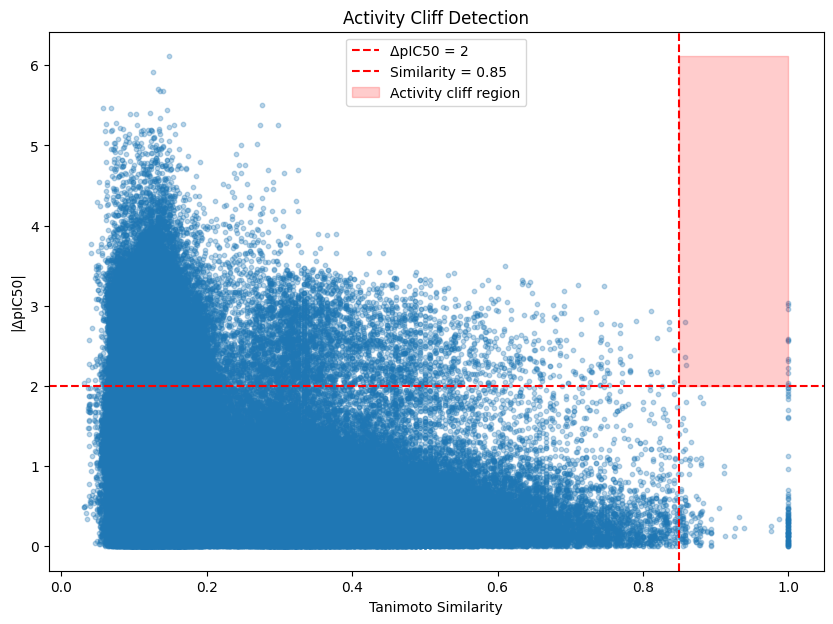

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate all pairwise similarities and activity differences (sampled)
sim_list, delta_pic50_list = [], []

for i in range(len(fps)):
    for j in range(i+1, len(fps)):
        sim = DataStructs.TanimotoSimilarity(fps[i], fps[j])
        delta = abs(pic50s[i] - pic50s[j])
        sim_list.append(sim)
        delta_pic50_list.append(delta)

plt.figure(figsize=(10, 7))
plt.scatter(sim_list, delta_pic50_list, alpha=0.3, s=10)
plt.axhline(y=2, color='red', linestyle='--', label='ΔpIC50 = 2')
plt.axvline(x=0.85, color='red', linestyle='--', label='Similarity = 0.85')
plt.fill_between([0.85, 1.0], 2, max(delta_pic50_list), alpha=0.2, color='red', label='Activity cliff region')
plt.xlabel('Tanimoto Similarity')
plt.ylabel('|ΔpIC50|')
plt.title('Activity Cliff Detection')
plt.legend()
plt.show()


##1.3 Chemical Structure Curation

###1.3.1 Structure Standardization Pipeline

In [ ]:
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit.Chem.SaltRemover import SaltRemover
from tqdm import tqdm

# Careful when using this. This suppresses all warnings from RDKit
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

# Enable tqdm for pandas
tqdm.pandas()

# Initialize standardization tools
salt_remover = SaltRemover()
uncharger = rdMolStandardize.Uncharger()
normalizer = rdMolStandardize.Normalizer()
tautomer_enumerator = rdMolStandardize.TautomerEnumerator()

def standardize_molecule(smiles):
    """
    Apply publication-grade molecular standardization.
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    try:
        # Remove salts (keep largest fragment)
        mol = salt_remover.StripMol(mol)

        # Normalize functional groups
        mol = normalizer.normalize(mol)

        # Neutralize charges
        mol = uncharger.uncharge(mol)

        # Canonicalize tautomers
        mol = tautomer_enumerator.Canonicalize(mol)

        # Return canonical SMILES
        return Chem.MolToSmiles(mol, canonical=True)

    except Exception:
        return None

# Apply standardization with progress bar
print("Standardizing molecular structures...")
df_valid['smiles_standardized'] = df_valid['canonical_smiles'].progress_apply(standardize_molecule)

n_before = len(df_valid)
df_curated = df_valid.dropna(subset=['smiles_standardized']).copy()
n_after = len(df_curated)
print(f"Standardization complete: {n_after:,} / {n_before:,} compounds retained")


Standardizing molecular structures...


100%|██████████| 806/806 [00:14<00:00, 54.18it/s]

Standardization complete: 806 / 806 compounds retained


###1.3.2 Duplicate Removal After Standardization

In [ ]:
# Check for duplicates after standardization
n_unique_before = df_curated['smiles_standardized'].nunique()
n_total = len(df_curated)

print(f"Total entries: {n_total:,}")
print(f"Unique standardized SMILES: {n_unique_before:,}")
print(f"New duplicates revealed: {n_total - n_unique_before:,}")

# Aggregate duplicates by taking median pIC50
df_final = df_curated.groupby('smiles_standardized').agg(
    molecule_chembl_id=('molecule_chembl_id', 'first'),
    pIC50=('pIC50', 'median'),
).reset_index()

df_final = df_final.rename(columns={'smiles_standardized': 'smiles'})
print(f"\nFinal curated dataset: {len(df_final):,} unique compounds")


Total entries: 806
Unique standardized SMILES: 806
New duplicates revealed: 0

Final curated dataset: 806 unique compounds


###1.3.3 Stereochemistry Handling

In [ ]:
import requests
from tqdm import tqdm

# Analyze stereochemistry in the dataset
tqdm.pandas(desc="Counting stereocenters")

def count_stereocenters(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return 0
    return len(Chem.FindMolChiralCenters(mol, includeUnassigned=True))

def has_undefined_stereo(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return False
    centers = Chem.FindMolChiralCenters(mol, includeUnassigned=True)
    return any(c[1] == '?' for c in centers)

# Analyze the dataset
df_final['n_stereocenters'] = df_final['smiles'].progress_apply(count_stereocenters)

tqdm.pandas(desc="Checking undefined stereo")
df_final['undefined_stereo'] = df_final['smiles'].progress_apply(has_undefined_stereo)

n_with_stereo = (df_final['n_stereocenters'] > 0).sum()
n_undefined = df_final['undefined_stereo'].sum()

print(f"Compounds with stereocenters: {n_with_stereo:,}")
print(f"Compounds with undefined stereochemistry: {n_undefined:,}")

# Query ChEMBL for original structures to resolve undefined stereochemistry
def batch_query_chembl(chembl_ids, batch_size=50):
    """Batch query ChEMBL for molfiles with better stereo annotation."""
    results = {}

    for i in tqdm(range(0, len(chembl_ids), batch_size), desc="Querying ChEMBL"):
        batch = chembl_ids[i:i+batch_size]
        ids_str = ";".join(batch)
        url = f"https://www.ebi.ac.uk/chembl/api/data/molecule/set/{ids_str}.sdf"

        try:
            response = requests.get(url, timeout=30)
            if response.status_code == 200:
                suppl = Chem.SDMolSupplier()
                suppl.SetData(response.text)
                for mol in suppl:
                    if mol and mol.HasProp('chembl_id'):
                        cid = mol.GetProp('chembl_id')
                        results[cid] = Chem.MolToSmiles(mol, isomericSmiles=True)
        except Exception as e:
            continue

    return results

if n_undefined > 0:
    print(f"\nQuerying ChEMBL for {n_undefined:,} compounds with undefined stereochemistry...")
    undefined_ids = df_final[df_final['undefined_stereo']]['molecule_chembl_id'].tolist()
    updated_smiles = batch_query_chembl(undefined_ids)

    # Update SMILES where ChEMBL returned a structure
    df_final['smiles'] = df_final.apply(
        lambda row: updated_smiles.get(row['molecule_chembl_id'], row['smiles']), axis=1
    )

    # Re-check undefined stereo after update
    tqdm.pandas(desc="Re-checking undefined stereo")
    df_final['undefined_stereo'] = df_final['smiles'].progress_apply(has_undefined_stereo)

    n_still_undefined = df_final['undefined_stereo'].sum()
    n_resolved = n_undefined - n_still_undefined

    print(f"\nStereochemistry resolved for {n_resolved:,} compounds")
    print(f"Still undefined: {n_still_undefined:,} compounds")
else:
    print("\nNo undefined stereochemistry to resolve.")


Checking undefined stereo: 100%|██████████| 806/806 [00:01<00:00, 711.58it/s]


Compounds with stereocenters: 601
Compounds with undefined stereochemistry: 406

Querying ChEMBL for 406 compounds with undefined stereochemistry...


Re-checking undefined stereo: 100%|██████████| 806/806 [00:00<00:00, 806.26it/s]


Stereochemistry resolved for 0 compounds
Still undefined: 406 compounds


###1.3.4 Quality Control Summary

In [ ]:
# Generate quality control summary
print("=" * 60)
print("DATA CURATION SUMMARY")
print("=" * 60)
print(f"Target: BRD2 (CHEMBL203)")
print(f"Endpoint: pIC50 (derived from IC50, nM)")
print(f"")
print(f"Dataset Statistics:")
print(f"  Total compounds: {len(df_final):,}")
print(f"  pIC50 range: {df_final['pIC50'].min():.2f} - {df_final['pIC50'].max():.2f}")
print(f"  pIC50 mean: {df_final['pIC50'].mean():.2f} ± {df_final['pIC50'].std():.2f}")

# Save curated dataset
output_file = 'DATASET_BRD2_ic50_cleaned_compounds.csv'
df_final.to_csv(output_file, index=False)
print(f"\nSaved: {output_file}")

# Download to local computer
from google.colab import files
files.download(output_file)


DATA CURATION SUMMARY
Target: BRD2 (CHEMBL203)
Endpoint: pIC50 (derived from IC50, nM)

Dataset Statistics:
  Total compounds: 806
  pIC50 range: 3.59 - 9.70
  pIC50 mean: 6.71 ± 0.96

Saved: DATASET_BRD2_ic50_cleaned_compounds.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Part 2: Molecular Representations

##2.1 Setup and Data Loading

In [29]:
!pip install rdkit -q

# Step 1: Import required libraries
import pandas as pd
import numpy as np
import io
from rdkit import Chem
from rdkit import __version__ as rdkit_version

print(f"RDKit version: {rdkit_version}")

# Step 2: Load the curated dataset from Part 1
# Try Google Colab upload first, fall back to ipywidgets
try:
    from google.colab import files
    print("Please upload your dataset file (DATASET_BRD2_ic50_cleaned_compounds):")
    uploaded = files.upload()
    filename = list(uploaded.keys())[0]
    file_content = uploaded[filename]
except ImportError:
    # For Jupyter Notebook
    import ipywidgets as widgets
    from IPython.display import display

    uploader = widgets.FileUpload(accept='.csv,.xlsx,.xls,.tsv', multiple=False)
    print("Please upload your dataset file (CSV, Excel, or TSV):")
    display(uploader)

    # Wait for upload
    import time
    while not uploader.value:
        time.sleep(0.1)

    filename = list(uploader.value.keys())[0]
    file_content = uploader.value[filename]['content']

# Read the file based on extension
if filename.endswith('.csv'):
    df = pd.read_csv(io.BytesIO(file_content))
elif filename.endswith(('.xlsx', '.xls')):
    df = pd.read_excel(io.BytesIO(file_content))
elif filename.endswith('.tsv'):
    df = pd.read_csv(io.BytesIO(file_content), sep='\t')
else:
    df = pd.read_csv(io.BytesIO(file_content))

print(f"Loaded '{filename}' with {len(df):,} rows and {len(df.columns)} columns")



RDKit version: 2025.09.6
Please upload your dataset file (DATASET_BRD2_ic50_cleaned_compounds):


Saving DATASET_BRD2_ic50_cleaned_compounds.csv to DATASET_BRD2_ic50_cleaned_compounds.csv
Loaded 'DATASET_BRD2_ic50_cleaned_compounds.csv' with 806 rows and 5 columns


##2.2 Chemical Fingerprints

###2.2.1 Morgan/ECFP Fingerprints

In [30]:
from rdkit.Chem import AllChem
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from tqdm import tqdm

# Enable tqdm for pandas
tqdm.pandas()

def generate_morgan_fingerprint(mol, radius=2, n_bits=2048):
    """
    Generate Morgan (ECFP) fingerprint as a bit vector.

    Parameters:
    - radius: 2 gives ECFP4, 3 gives ECFP6
    - n_bits: fingerprint length (2048 is standard)

    Returns numpy array of shape (n_bits,)
    """
    if mol is None:
        return None

    # Use the new MorganGenerator API
    generator = GetMorganGenerator(radius=radius, fpSize=n_bits)
    fp = generator.GetFingerprintAsNumPy(mol)
    return fp

# Create RDKit Mol objects from SMILES
df['mol'] = df['smiles'].apply(Chem.MolFromSmiles)

# Check for any failures
n_failed = df['mol'].isna().sum()
print(f"Successfully converted: {len(df) - n_failed} | Failed: {n_failed}")

# Drop any rows where conversion failed
if n_failed > 0:
    df = df.dropna(subset=['mol']).reset_index(drop=True)

# Generate ECFP4 fingerprints for all compounds
print("Generating Morgan/ECFP4 fingerprints (radius=2, 2048 bits)...")
ecfp4_fps = df['mol'].progress_apply(lambda m: generate_morgan_fingerprint(m, radius=2, n_bits=2048))

# Convert to DataFrame with meaningful column names
ecfp4_matrix = np.vstack(ecfp4_fps.values)
ecfp4_columns = [f'ECFP4_{i}' for i in range(2048)]
df_ecfp4 = pd.DataFrame(ecfp4_matrix, columns=ecfp4_columns, index=df.index)

print(f"ECFP4 fingerprint matrix shape: {df_ecfp4.shape}")
print(f"Bits set per molecule (mean): {ecfp4_matrix.sum(axis=1).mean():.1f}")


Successfully converted: 806 | Failed: 0
Generating Morgan/ECFP4 fingerprints (radius=2, 2048 bits)...


100%|██████████| 806/806 [00:00<00:00, 1328.19it/s]


ECFP4 fingerprint matrix shape: (806, 2048)
Bits set per molecule (mean): 57.2


###2.2.2 MACCS Keys

In [31]:
from rdkit.Chem import MACCSkeys
from tqdm import tqdm

tqdm.pandas()

def generate_maccs_fingerprint(mol):
    """
    Generate MACCS keys fingerprint (166 bits).

    MACCS keys are predefined structural patterns.
    Each bit has a known chemical interpretation.
    """
    if mol is None:
        return None
    fp = MACCSkeys.GenMACCSKeys(mol)
    return np.array(fp)

# Generate MACCS fingerprints for all compounds
print("Generating MACCS key fingerprints (166 bits)...")
maccs_fps = df['mol'].progress_apply(generate_maccs_fingerprint)

# Convert to DataFrame
maccs_matrix = np.vstack(maccs_fps.values)
maccs_columns = [f'MACCS_{i}' for i in range(167)]  # MACCS has 167 bits (0-166)
df_maccs = pd.DataFrame(maccs_matrix, columns=maccs_columns, index=df.index)

print(f"MACCS fingerprint matrix shape: {df_maccs.shape}")
print(f"Bits set per molecule (mean): {maccs_matrix.sum(axis=1).mean():.1f}")


Generating MACCS key fingerprints (166 bits)...


100%|██████████| 806/806 [00:03<00:00, 245.52it/s]

MACCS fingerprint matrix shape: (806, 167)
Bits set per molecule (mean): 57.7


###2.2.3 RDKit Topological Fingerprints

In [32]:
from rdkit.Chem import RDKFingerprint
from tqdm import tqdm

# Enable tqdm for pandas
tqdm.pandas()

def generate_rdkit_fingerprint(mol, n_bits=2048):
    """
    Generate RDKit topological fingerprint.

    Encodes hashed paths through the molecular graph.
    Complementary to circular fingerprints like ECFP.
    """
    if mol is None:
        return None
    fp = RDKFingerprint(mol, fpSize=n_bits)
    return np.array(fp)

# Generate RDKit fingerprints for all compounds
print("Generating RDKit topological fingerprints (2048 bits)...")
rdkit_fps = df['mol'].progress_apply(lambda m: generate_rdkit_fingerprint(m, n_bits=2048))

# Convert to DataFrame
rdkit_matrix = np.vstack(rdkit_fps.values)
rdkit_columns = [f'RDKit_{i}' for i in range(2048)]
df_rdkit = pd.DataFrame(rdkit_matrix, columns=rdkit_columns, index=df.index)

print(f"RDKit fingerprint matrix shape: {df_rdkit.shape}")
print(f"Bits set per molecule (mean): {rdkit_matrix.sum(axis=1).mean():.1f}")


Generating RDKit topological fingerprints (2048 bits)...


100%|██████████| 806/806 [00:11<00:00, 71.92it/s]


RDKit fingerprint matrix shape: (806, 2048)
Bits set per molecule (mean): 1420.5


##2.3 Molecular Descriptors

###2.3.1 RDKit 2D Descriptor Calculation

In [33]:
from rdkit.Chem import Descriptors
from rdkit.ML.Descriptors import MoleculeDescriptors
from tqdm import tqdm

# Enable tqdm for pandas
tqdm.pandas()

# Step 1: Get the list of all available 2D descriptors
descriptor_names = [desc[0] for desc in Descriptors.descList]
print(f"Total RDKit 2D descriptors available: {len(descriptor_names)}")

# Step 2: Create a descriptor calculator
calculator = MoleculeDescriptors.MolecularDescriptorCalculator(descriptor_names)

# Step 3: Calculate descriptors for all molecules
def calculate_descriptors(mol):
    """Calculate all RDKit 2D descriptors for a molecule."""
    if mol is None:
        return [np.nan] * len(descriptor_names)
    try:
        return list(calculator.CalcDescriptors(mol))
    except Exception:
        return [np.nan] * len(descriptor_names)

print("Calculating molecular descriptors...")
descriptor_values = df['mol'].progress_apply(calculate_descriptors)

# Step 4: Convert to DataFrame
df_descriptors = pd.DataFrame(
    descriptor_values.tolist(),
    columns=descriptor_names,
    index=df.index
)

print(f"Descriptor matrix shape: {df_descriptors.shape}")


Total RDKit 2D descriptors available: 217
Calculating molecular descriptors...


100%|██████████| 806/806 [00:16<00:00, 50.10it/s]

Descriptor matrix shape: (806, 217)


###2.3.2 Descriptor Quality Control

In [34]:
from tqdm import tqdm

# Step 1: Replace infinite values with NaN
df_descriptors = df_descriptors.replace([np.inf, -np.inf], np.nan)

# Step 2: Count missing values per descriptor
missing_counts = df_descriptors.isna().sum()
high_missing = missing_counts[missing_counts > len(df) * 0.1]  # >10% missing
print(f"Descriptors with >10% missing values: {len(high_missing)}")

# Step 3: Remove descriptors with >10% missing values
valid_descriptors = missing_counts[missing_counts <= len(df) * 0.1].index.tolist()
df_descriptors_clean = df_descriptors[valid_descriptors].copy()
print(f"Descriptors retained: {len(valid_descriptors)}")

# Step 4: Fill remaining missing values with column median
# Median is robust to outliers
for col in tqdm(df_descriptors_clean.columns, desc="Filling missing values"):
    median_val = df_descriptors_clean[col].median()
    df_descriptors_clean[col] = df_descriptors_clean[col].fillna(median_val)

# Step 5: Verify no missing values remain
remaining_nan = df_descriptors_clean.isna().sum().sum()
print(f"Remaining missing values: {remaining_nan}")


Descriptors with >10% missing values: 0
Descriptors retained: 217


Filling missing values: 100%|██████████| 217/217 [00:00<00:00, 4086.71it/s]

Remaining missing values: 0


###2.3.3 Removing Low-Variance Descriptors

In [35]:
from sklearn.feature_selection import VarianceThreshold
from tqdm import tqdm

# Create progress bar for the steps
steps = ['Calculate variance', 'Count zero-variance', 'Apply threshold filter',
         'Get selected features', 'Create filtered DataFrame']

with tqdm(total=len(steps), desc="Variance Filtering") as pbar:
    # Step 1: Calculate variance for each descriptor
    pbar.set_description("Calculating variance")
    variances = df_descriptors_clean.var()
    print(f"\nVariance range: {variances.min():.6f} to {variances.max():.2f}")
    pbar.update(1)

    # Step 2: Count zero-variance descriptors
    pbar.set_description("Counting zero-variance")
    zero_var = (variances == 0).sum()
    print(f"Zero-variance descriptors: {zero_var}")
    pbar.update(1)

    # Step 3: Apply variance threshold filter
    pbar.set_description("Applying threshold filter")
    selector = VarianceThreshold(threshold=0.01)
    selector.fit(df_descriptors_clean)
    pbar.update(1)

    # Step 4: Get selected feature names
    pbar.set_description("Getting selected features")
    selected_mask = selector.get_support()
    selected_descriptors = df_descriptors_clean.columns[selected_mask].tolist()
    print(f"Descriptors after variance filter: {len(selected_descriptors)}")
    pbar.update(1)

    # Step 5: Create filtered descriptor DataFrame
    pbar.set_description("Creating filtered DataFrame")
    df_descriptors_filtered = df_descriptors_clean[selected_descriptors].copy()
    print(f"Final descriptor matrix shape: {df_descriptors_filtered.shape}")
    pbar.update(1)

    pbar.set_description("Complete")


Complete: 100%|██████████| 5/5 [00:00<00:00, 158.90it/s]


Variance range: 0.000000 to 14699556254594865152.00
Zero-variance descriptors: 25
Descriptors after variance filter: 159
Final descriptor matrix shape: (806, 159)


###2.3.4 Removing Highly Correlated Descriptors

In [36]:
from tqdm import tqdm

def remove_correlated_features(df, threshold=0.95):
    """
    Remove highly correlated features from a DataFrame.

    For each pair with |correlation| > threshold, removes the
    feature with higher mean absolute correlation to all others.

    Parameters:
    - df: DataFrame of features
    - threshold: correlation threshold (default 0.95)

    Returns: list of features to keep
    """
    # Calculate correlation matrix
    corr_matrix = df.corr().abs()

    # Get upper triangle (avoid duplicate pairs)
    upper_tri = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    # Find features to drop
    to_drop = set()
    for col in tqdm(upper_tri.columns, desc="Checking correlations"):
        # Find features correlated above threshold with this column
        correlated = upper_tri.index[upper_tri[col] > threshold].tolist()
        for corr_feat in correlated:
            # Keep feature with lower mean correlation
            if corr_matrix[col].mean() > corr_matrix[corr_feat].mean():
                to_drop.add(col)
            else:
                to_drop.add(corr_feat)

    return [c for c in df.columns if c not in to_drop]

# Apply correlation filter
print("Removing highly correlated descriptors (threshold=0.95)...")
uncorrelated_descriptors = remove_correlated_features(df_descriptors_filtered, threshold=0.95)
df_descriptors_final = df_descriptors_filtered[uncorrelated_descriptors].copy()

print(f"Descriptors before correlation filter: {len(df_descriptors_filtered.columns)}")
print(f"Descriptors after correlation filter: {len(uncorrelated_descriptors)}")
print(f"Removed {len(df_descriptors_filtered.columns) - len(uncorrelated_descriptors)} correlated features")


Removing highly correlated descriptors (threshold=0.95)...


Checking correlations: 100%|██████████| 159/159 [00:00<00:00, 3596.44it/s]

Descriptors before correlation filter: 159
Descriptors after correlation filter: 131
Removed 28 correlated features


##2.4 Feature Matrix Assembly

###2.4.1 Assembling the Fingerprint Dataset

In [37]:
# Step 1: Create metadata columns
df_metadata = df[['molecule_chembl_id', 'smiles', 'pIC50']].copy()

# Step 2: Combine all fingerprints
df_fingerprints_combined = pd.concat([
    df_metadata.reset_index(drop=True),
    df_ecfp4.reset_index(drop=True),
    df_maccs.reset_index(drop=True),
    df_rdkit.reset_index(drop=True)
], axis=1)

print(f"Combined fingerprint dataset shape: {df_fingerprints_combined.shape}")
print(f"  - Metadata columns: 3")
print(f"  - ECFP4 bits: {df_ecfp4.shape[1]}")
print(f"  - MACCS bits: {df_maccs.shape[1]}")
print(f"  - RDKit bits: {df_rdkit.shape[1]}")

# Step 3: Also create individual fingerprint files for comparison studies
df_ecfp4_final = pd.concat([df_metadata.reset_index(drop=True), df_ecfp4.reset_index(drop=True)], axis=1)
df_maccs_final = pd.concat([df_metadata.reset_index(drop=True), df_maccs.reset_index(drop=True)], axis=1)
df_rdkit_final = pd.concat([df_metadata.reset_index(drop=True), df_rdkit.reset_index(drop=True)], axis=1)


Combined fingerprint dataset shape: (806, 4266)
  - Metadata columns: 3
  - ECFP4 bits: 2048
  - MACCS bits: 167
  - RDKit bits: 2048


###2.4.2 Assembling the Descriptor Dataset

In [38]:
# Assemble descriptor dataset
df_descriptors_dataset = pd.concat([
    df_metadata.reset_index(drop=True),
    df_descriptors_final.reset_index(drop=True)
], axis=1)

print(f"Descriptor dataset shape: {df_descriptors_dataset.shape}")
print(f"  - Metadata columns: 3")
print(f"  - Descriptor features: {df_descriptors_final.shape[1]}")


Descriptor dataset shape: (806, 134)
  - Metadata columns: 3
  - Descriptor features: 131


###2.4.3 Saving Feature Matrices

In [39]:
from google.colab import files

# Save all feature matrices
print("Saving feature matrices...")

# Combined fingerprints
df_fingerprints_combined.to_csv('DATASET_BRD2_fingerprints_combined.csv', index=False)
print(f"  Saved: DATASET_BRD2_fingerprints_combined.csv ({df_fingerprints_combined.shape})")

# Individual fingerprint types (for comparative studies)
df_ecfp4_final.to_csv('DATASET_BRD2_fingerprints_ecfp4.csv', index=False)
print(f"  Saved: DATASET_BRD2_fingerprints_ecfp4.csv ({df_ecfp4_final.shape})")

df_maccs_final.to_csv('DATASET_BRD2_fingerprints_maccs.csv', index=False)
print(f"  Saved: DATASET_BRD2_fingerprints_maccs.csv ({df_maccs_final.shape})")

df_rdkit_final.to_csv('DATASET_BRD2_fingerprints_rdkit.csv', index=False)
print(f"  Saved: DATASET_BRD2_fingerprints_rdkit.csv ({df_rdkit_final.shape})")

# Molecular descriptors
df_descriptors_dataset.to_csv('DATASET_BRD2_descriptors.csv', index=False)
print(f"  Saved: DATASET_BRD2_descriptors.csv ({df_descriptors_dataset.shape})")

print("\nAll feature matrices saved successfully.")

# Download all files
print("\nDownloading files...")
files.download('DATASET_BRD2_fingerprints_combined.csv')
files.download('DATASET_BRD2_fingerprints_ecfp4.csv')
files.download('DATASET_BRD2_fingerprints_maccs.csv')
files.download('DATASET_BRD2_fingerprints_rdkit.csv')
files.download('DATASET_BRD2_descriptors.csv')


Saving feature matrices...
  Saved: DATASET_BRD2_fingerprints_combined.csv ((806, 4266))
  Saved: DATASET_BRD2_fingerprints_ecfp4.csv ((806, 2051))
  Saved: DATASET_BRD2_fingerprints_maccs.csv ((806, 170))
  Saved: DATASET_BRD2_fingerprints_rdkit.csv ((806, 2051))
  Saved: DATASET_BRD2_descriptors.csv ((806, 134))

All feature matrices saved successfully.



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Part 3: Dataset Splitting

##3.1 Scaffold-Based Splitting

###3.1.1 Bemis-Murcko Scaffold Extraction

In [41]:
import numpy as np
import pandas as pd
import io

def upload_and_load_file(var_name, expected_filename=None):
    """
    Prompt user to upload a file and return as DataFrame.

    Parameters:
        var_name: Name of the variable (for display purposes)
        expected_filename: Suggested filename to help user identify the file
    """
    prompt_msg = f"Please upload the file for '{var_name}'"
    if expected_filename:
        prompt_msg += f" (expected: {expected_filename})"
    prompt_msg += ":"

    # Try Google Colab upload first, fall back to ipywidgets
    try:
        from google.colab import files
        print(prompt_msg)
        uploaded = files.upload()
        filename = list(uploaded.keys())[0]
        file_content = uploaded[filename]
    except ImportError:
        # For Jupyter Notebook
        import ipywidgets as widgets
        from IPython.display import display
        import time

        uploader = widgets.FileUpload(accept='.csv,.xlsx,.xls,.tsv', multiple=False)
        print(prompt_msg)
        display(uploader)

        # Wait for upload
        while not uploader.value:
            time.sleep(0.1)

        filename = list(uploader.value.keys())[0]
        file_content = uploader.value[filename]['content']

    # Read the file based on extension
    if filename.endswith('.csv'):
        df_loaded = pd.read_csv(io.BytesIO(file_content))
    elif filename.endswith(('.xlsx', '.xls')):
        df_loaded = pd.read_excel(io.BytesIO(file_content))
    elif filename.endswith('.tsv'):
        df_loaded = pd.read_csv(io.BytesIO(file_content), sep='\t')
    else:
        df_loaded = pd.read_csv(io.BytesIO(file_content))

    print(f"  ✓ Loaded '{filename}' with {len(df_loaded):,} rows and {len(df_loaded.columns)} columns\n")
    return df_loaded

# Define required datasets with their expected filenames
required_datasets = {
    'df': 'DATASET_BRD2_ic50_cleaned_compounds.csv',
    'df_desc': 'DATASET_BRD2_descriptors.csv',
    'df_fp_ecfp4': 'DATASET_BRD2_fingerprints_ecfp4.csv',
    'df_fp_maccs': 'DATASET_BRD2_fingerprints_maccs.csv',
    'df_fp_rdkit': 'DATASET_BRD2_fingerprints_rdkit.csv',
    'df_fp_combined': 'DATASET_BRD2_fingerprints_combined.csv'
}

# Check each dataframe and prompt for upload if not defined
if 'df' not in dir():
    df = upload_and_load_file('df', required_datasets['df'])

if 'df_desc' not in dir():
    df_desc = upload_and_load_file('df_desc', required_datasets['df_desc'])

if 'df_fp_ecfp4' not in dir():
    df_fp_ecfp4 = upload_and_load_file('df_fp_ecfp4', required_datasets['df_fp_ecfp4'])

if 'df_fp_maccs' not in dir():
    df_fp_maccs = upload_and_load_file('df_fp_maccs', required_datasets['df_fp_maccs'])

if 'df_fp_rdkit' not in dir():
    df_fp_rdkit = upload_and_load_file('df_fp_rdkit', required_datasets['df_fp_rdkit'])

if 'df_fp_combined' not in dir():
    df_fp_combined = upload_and_load_file('df_fp_combined', required_datasets['df_fp_combined'])

# Summary of loaded datasets
print("=" * 60)
print("Dataset Summary:")
print("=" * 60)
print(f"  df (cleaned compounds): {len(df):,} rows × {len(df.columns)} columns")
print(f"  df_desc:                {len(df_desc):,} rows × {len(df_desc.columns)} columns")
print(f"  df_fp_ecfp4:            {len(df_fp_ecfp4):,} rows × {len(df_fp_ecfp4.columns)} columns")
print(f"  df_fp_maccs:            {len(df_fp_maccs):,} rows × {len(df_fp_maccs.columns)} columns")
print(f"  df_fp_rdkit:            {len(df_fp_rdkit):,} rows × {len(df_fp_rdkit.columns)} columns")
print(f"  df_fp_combined:         {len(df_fp_combined):,} rows × {len(df_fp_combined.columns)} columns")
print("=" * 60)


Please upload the file for 'df_desc' (expected: DATASET_BRD2_descriptors.csv):


Saving DATASET_BRD2_descriptors.csv to DATASET_BRD2_descriptors (1).csv
  ✓ Loaded 'DATASET_BRD2_descriptors (1).csv' with 806 rows and 134 columns

Please upload the file for 'df_fp_ecfp4' (expected: DATASET_BRD2_fingerprints_ecfp4.csv):


Saving DATASET_BRD2_fingerprints_ecfp4.csv to DATASET_BRD2_fingerprints_ecfp4 (1).csv
  ✓ Loaded 'DATASET_BRD2_fingerprints_ecfp4 (1).csv' with 806 rows and 2051 columns

Please upload the file for 'df_fp_maccs' (expected: DATASET_BRD2_fingerprints_maccs.csv):


Saving DATASET_BRD2_fingerprints_maccs.csv to DATASET_BRD2_fingerprints_maccs (1).csv
  ✓ Loaded 'DATASET_BRD2_fingerprints_maccs (1).csv' with 806 rows and 170 columns

Please upload the file for 'df_fp_rdkit' (expected: DATASET_BRD2_fingerprints_rdkit.csv):


Saving DATASET_BRD2_fingerprints_rdkit.csv to DATASET_BRD2_fingerprints_rdkit (1).csv
  ✓ Loaded 'DATASET_BRD2_fingerprints_rdkit (1).csv' with 806 rows and 2051 columns

Please upload the file for 'df_fp_combined' (expected: DATASET_BRD2_fingerprints_combined.csv):


Saving DATASET_BRD2_fingerprints_combined.csv to DATASET_BRD2_fingerprints_combined (1).csv
  ✓ Loaded 'DATASET_BRD2_fingerprints_combined (1).csv' with 806 rows and 4266 columns

Dataset Summary:
  df (cleaned compounds): 806 rows × 6 columns
  df_desc:                806 rows × 134 columns
  df_fp_ecfp4:            806 rows × 2051 columns
  df_fp_maccs:            806 rows × 170 columns
  df_fp_rdkit:            806 rows × 2051 columns
  df_fp_combined:         806 rows × 4266 columns


In [42]:
!pip install rdkit -q
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold

# Generate Murcko scaffolds for each molecule
def get_murcko_scaffold(smiles):
    """Extract Murcko scaffold from SMILES string."""
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        scaffold = MurckoScaffold.GetScaffoldForMol(mol)
        return Chem.MolToSmiles(scaffold)
    except:
        return None

# Apply scaffold generation
print("Generating Murcko scaffolds...")
df['scaffold'] = df['smiles'].apply(get_murcko_scaffold)

# Filter out compounds where scaffold generation failed
df_valid = df[df['scaffold'].notna()].copy()

print(f"Compounds with valid scaffolds: {len(df_valid):,} / {len(df):,}")
print(f"Failed scaffold generation: {len(df) - len(df_valid):,}")


Generating Murcko scaffolds...
Compounds with valid scaffolds: 806 / 806
Failed scaffold generation: 0


In [43]:
from collections import Counter

# Count compounds per scaffold
scaffold_counts = Counter(df_valid['scaffold'])

print(f"Total unique scaffolds: {len(scaffold_counts):,}")
print(f"\nScaffold distribution:")
print(f"  Singletons (1 compound): {sum(1 for c in scaffold_counts.values() if c == 1):,}")
print(f"  Small series (2-5): {sum(1 for c in scaffold_counts.values() if 2 <= c <= 5):,}")
print(f"  Medium series (6-20): {sum(1 for c in scaffold_counts.values() if 6 <= c <= 20):,}")
print(f"  Large series (>20): {sum(1 for c in scaffold_counts.values() if c > 20):,}")

# Show top 10 most common scaffolds
print(f"\nTop 10 scaffolds by compound count:")
for scaffold, count in scaffold_counts.most_common(10):
    print(f"  {count:4d} compounds: {scaffold[:50]}..." if len(scaffold) > 50 else f"  {count:4d} compounds: {scaffold}")


Total unique scaffolds: 397

Scaffold distribution:
  Singletons (1 compound): 261
  Small series (2-5): 111
  Medium series (6-20): 24
  Large series (>20): 1

Top 10 scaffolds by compound count:
    22 compounds: c1ccc(N[C@@H]2CCNc3ccc(-c4ccccc4)cc32)cc1
    19 compounds: O=C1c2n[nH]cc2C(c2ccccc2)N1c1ccc(=O)[nH]c1
    17 compounds: O=C1c2cc[nH]c2C(c2ccccc2)N1c1ccc(=O)[nH]c1
    16 compounds: O=C1c2cc[nH]c2C(c2ccccc2)N1c1ccc2nncn2c1
    15 compounds: c1ccc(N2CCn3nncc3-c3ccccc32)cc1
    14 compounds: O=C1c2[nH]ncc2C(c2ccccc2)N1c1ccc(=O)[nH]c1
    13 compounds: c1ccc(-c2cnoc2)cc1
    12 compounds: O=C1c2nc(C3=CCNCC3)[nH]c2C(c2ccccc2)N1c1ccc2nncn2c...
    12 compounds: O=S(=O)(Nc1ccccc1)c1cccc(-c2cnoc2)c1
    11 compounds: O=C1c2c(cnn2C2CC2)C(c2ccccc2)N1c1ccc(=O)[nH]c1


###3.2.2 Implementing Scaffold Split

In [44]:
def scaffold_split(df, smiles_col='smiles', test_size=0.1, val_size=0.1, random_state=42):
    """
    Perform scaffold-based train/validation/test split.

    All molecules sharing a scaffold are assigned to the same partition.
    Scaffolds are sorted by size (largest first) for balanced splits.

    Returns: train_idx, val_idx, test_idx (lists of DataFrame indices)
    """
    np.random.seed(random_state)

    # Extract scaffolds
    scaffolds = df[smiles_col].apply(get_murcko_scaffold)

    # Group indices by scaffold
    scaffold_to_indices = {}
    for idx, scaffold in zip(df.index, scaffolds):
        if scaffold is None:
            scaffold = f'NONE_{idx}'  # Treat parsing failures as singletons
        if scaffold not in scaffold_to_indices:
            scaffold_to_indices[scaffold] = []
        scaffold_to_indices[scaffold].append(idx)

    # Sort scaffolds by size (largest first) for better balance
    scaffold_sets = list(scaffold_to_indices.values())
    scaffold_sets.sort(key=len, reverse=True)

    # Calculate target sizes
    n_total = len(df)
    n_test = int(n_total * test_size)
    n_val = int(n_total * val_size)

    # Assign scaffolds to splits
    train_idx, val_idx, test_idx = [], [], []

    for indices in scaffold_sets:
        # Assign to smallest partition that hasn't reached target
        if len(test_idx) < n_test:
            test_idx.extend(indices)
        elif len(val_idx) < n_val:
            val_idx.extend(indices)
        else:
            train_idx.extend(indices)

    return train_idx, val_idx, test_idx


In [45]:
# Perform scaffold-based split
train_idx, val_idx, test_idx = scaffold_split(
    df_valid,
    smiles_col='smiles',
    test_size=0.1,
    val_size=0.1,
    random_state=42
)

# Create split DataFrames
df_train = df_valid.loc[train_idx].copy()
df_val = df_valid.loc[val_idx].copy()
df_test = df_valid.loc[test_idx].copy()

print(f"Scaffold-based split:")
print(f"  Train: {len(df_train):,} compounds ({100*len(df_train)/len(df_valid):.1f}%)")
print(f"  Val:   {len(df_val):,} compounds ({100*len(df_val)/len(df_valid):.1f}%)")
print(f"  Test:  {len(df_test):,} compounds ({100*len(df_test)/len(df_valid):.1f}%)")


Scaffold-based split:
  Train: 635 compounds (78.8%)
  Val:   82 compounds (10.2%)
  Test:  89 compounds (11.0%)


###3.1.3 Verifying Split Integrity

In [46]:
# Verify zero scaffold overlap
train_scaffolds = set(df_train['scaffold'])
val_scaffolds = set(df_val['scaffold'])
test_scaffolds = set(df_test['scaffold'])

train_val_overlap = train_scaffolds.intersection(val_scaffolds)
train_test_overlap = train_scaffolds.intersection(test_scaffolds)
val_test_overlap = val_scaffolds.intersection(test_scaffolds)

print("Scaffold Overlap Verification:")
print(f"  Train-Val overlap: {len(train_val_overlap)} scaffolds")
print(f"  Train-Test overlap: {len(train_test_overlap)} scaffolds")
print(f"  Val-Test overlap: {len(val_test_overlap)} scaffolds")

if len(train_val_overlap) == 0 and len(train_test_overlap) == 0 and len(val_test_overlap) == 0:
    print("\n[SUCCESS] Zero scaffold overlap - split integrity verified!")
else:
    print("\n[ERROR] Scaffold overlap detected - check implementation!")


Scaffold Overlap Verification:
  Train-Val overlap: 0 scaffolds
  Train-Test overlap: 0 scaffolds
  Val-Test overlap: 0 scaffolds

[SUCCESS] Zero scaffold overlap - split integrity verified!


##3.2 Activity Distribution Analysis

In [47]:
# Analyze pIC50 distributions across splits
print("pIC50 Distribution Analysis:")
print(f"{'Partition':<10} {'Count':>8} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
print("-" * 58)

for name, data in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    print(f"{name:<10} {len(data):>8,} {data['pIC50'].mean():>8.2f} {data['pIC50'].std():>8.2f} {data['pIC50'].min():>8.2f} {data['pIC50'].max():>8.2f}")

print("-" * 58)
print(f"{'Total':<10} {len(df_valid):>8,} {df_valid['pIC50'].mean():>8.2f} {df_valid['pIC50'].std():>8.2f} {df_valid['pIC50'].min():>8.2f} {df_valid['pIC50'].max():>8.2f}")


pIC50 Distribution Analysis:
Partition     Count     Mean      Std      Min      Max
----------------------------------------------------------
Train           635     6.76     1.00     3.59     9.70
Val              82     6.38     0.90     4.46     7.80
Test             89     6.64     0.57     5.20     7.80
----------------------------------------------------------
Total           806     6.71     0.96     3.59     9.70


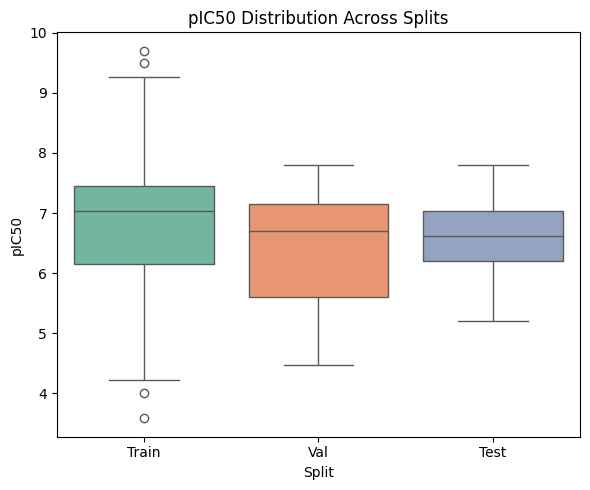

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Combine data with labels
df_train['Split'] = 'Train'
df_val['Split'] = 'Val'
df_test['Split'] = 'Test'
df_combined = pd.concat([df_train, df_val, df_test])

# Box plot
plt.figure(figsize=(6, 5))
sns.boxplot(data=df_combined, x='Split', y='pIC50', hue='Split',
            order=['Train', 'Val', 'Test'], palette='Set2', legend=False)
plt.title('pIC50 Distribution Across Splits')
plt.tight_layout()
plt.show()


##3.3 Creating Split Feature Matrices

###3.3.1 Splitting Fingerprint Matrices

In [49]:
# Create index mapping from SMILES to row position
# This handles potential ordering differences between files
smiles_to_split = {}
for idx in train_idx:
    smiles_to_split[df_valid.loc[idx, 'smiles']] = 'train'
for idx in val_idx:
    smiles_to_split[df_valid.loc[idx, 'smiles']] = 'val'
for idx in test_idx:
    smiles_to_split[df_valid.loc[idx, 'smiles']] = 'test'

def split_by_smiles(df, smiles_col='smiles'):
    """Split DataFrame using SMILES-based assignment."""
    df['split'] = df[smiles_col].map(smiles_to_split)
    train = df[df['split'] == 'train'].drop(columns=['split'])
    val = df[df['split'] == 'val'].drop(columns=['split'])
    test = df[df['split'] == 'test'].drop(columns=['split'])
    return train, val, test

# Split all fingerprint datasets
fp_ecfp4_train, fp_ecfp4_val, fp_ecfp4_test = split_by_smiles(df_fp_ecfp4)
fp_maccs_train, fp_maccs_val, fp_maccs_test = split_by_smiles(df_fp_maccs)
fp_rdkit_train, fp_rdkit_val, fp_rdkit_test = split_by_smiles(df_fp_rdkit)
fp_combined_train, fp_combined_val, fp_combined_test = split_by_smiles(df_fp_combined)

print(f"\nECFP4 split: train={len(fp_ecfp4_train)}, val={len(fp_ecfp4_val)}, test={len(fp_ecfp4_test)}")
print(f"MACCS split: train={len(fp_maccs_train)}, val={len(fp_maccs_val)}, test={len(fp_maccs_test)}")



ECFP4 split: train=635, val=82, test=89
MACCS split: train=635, val=82, test=89


###3.3.2 Splitting Descriptor Matrix

In [50]:
# Split descriptor dataset

desc_train, desc_val, desc_test = split_by_smiles(df_desc)
print(f"Descriptor split: train={len(desc_train)}, val={len(desc_val)}, test={len(desc_test)}")


Descriptor split: train=635, val=82, test=89


###3.3.3 Saving Split Datasets

In [52]:
import os
import shutil

# Create splits directory
os.makedirs('splits', exist_ok=True)

# Save ECFP4 splits
fp_ecfp4_train.to_csv('splits/DATASET_ecfp4_train.csv', index=False)
fp_ecfp4_val.to_csv('splits/DATASET_ecfp4_val.csv', index=False)
fp_ecfp4_test.to_csv('splits/DATASET_ecfp4_test.csv', index=False)

# Save MACCS splits
fp_maccs_train.to_csv('splits/DATASET_maccs_train.csv', index=False)
fp_maccs_val.to_csv('splits/DATASET_maccs_val.csv', index=False)
fp_maccs_test.to_csv('splits/DATASET_maccs_test.csv', index=False)

# Save RDKit fingerprint splits
fp_rdkit_train.to_csv('splits/DATASET_rdkit_fp_train.csv', index=False)
fp_rdkit_val.to_csv('splits/DATASET_rdkit_fp_val.csv', index=False)
fp_rdkit_test.to_csv('splits/DATASET_rdkit_fp_test.csv', index=False)

# Save combined fingerprint splits
fp_combined_train.to_csv('splits/DATASET_fingerprints_combined_train.csv', index=False)
fp_combined_val.to_csv('splits/DATASET_fingerprints_combined_val.csv', index=False)
fp_combined_test.to_csv('splits/DATASET_fingerprints_combined_test.csv', index=False)

# Save descriptor splits
desc_train.to_csv('splits/DATASET_descriptors_train.csv', index=False)
desc_val.to_csv('splits/DATASET_descriptors_val.csv', index=False)
desc_test.to_csv('splits/DATASET_descriptors_test.csv', index=False)

print("All split datasets saved to 'splits/' directory")
print(f"Files created: {len(os.listdir('splits'))}")

# Create zip file for download
shutil.make_archive('splits', 'zip', '.', 'splits')
print("\nCreated 'splits.zip' for download")

# If using Google Colab, uncomment below to trigger download:
from google.colab import files
files.download('splits.zip')


All split datasets saved to 'splits/' directory
Files created: 15

Created 'splits.zip' for download


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

###3.3.4 Visualizing Chemical Space Coverage in Train, Test and Split Subsets


ECFP4:
  Feature columns: 2048
  Excluded columns: ['molecule_chembl_id', 'smiles', 'pIC50']
  Train: 635, Val: 82, Test: 89

MACCS:
  Feature columns: 167
  Excluded columns: ['molecule_chembl_id', 'smiles', 'pIC50']
  Train: 635, Val: 82, Test: 89

RDKit Fingerprints:
  Feature columns: 2048
  Excluded columns: ['molecule_chembl_id', 'smiles', 'pIC50']
  Train: 635, Val: 82, Test: 89

Combined Fingerprints:
  Feature columns: 4263
  Excluded columns: ['molecule_chembl_id', 'smiles', 'pIC50']
  Train: 635, Val: 82, Test: 89

Descriptors:
  Feature columns: 131
  Excluded columns: ['molecule_chembl_id', 'smiles', 'pIC50']
  Train: 635, Val: 82, Test: 89


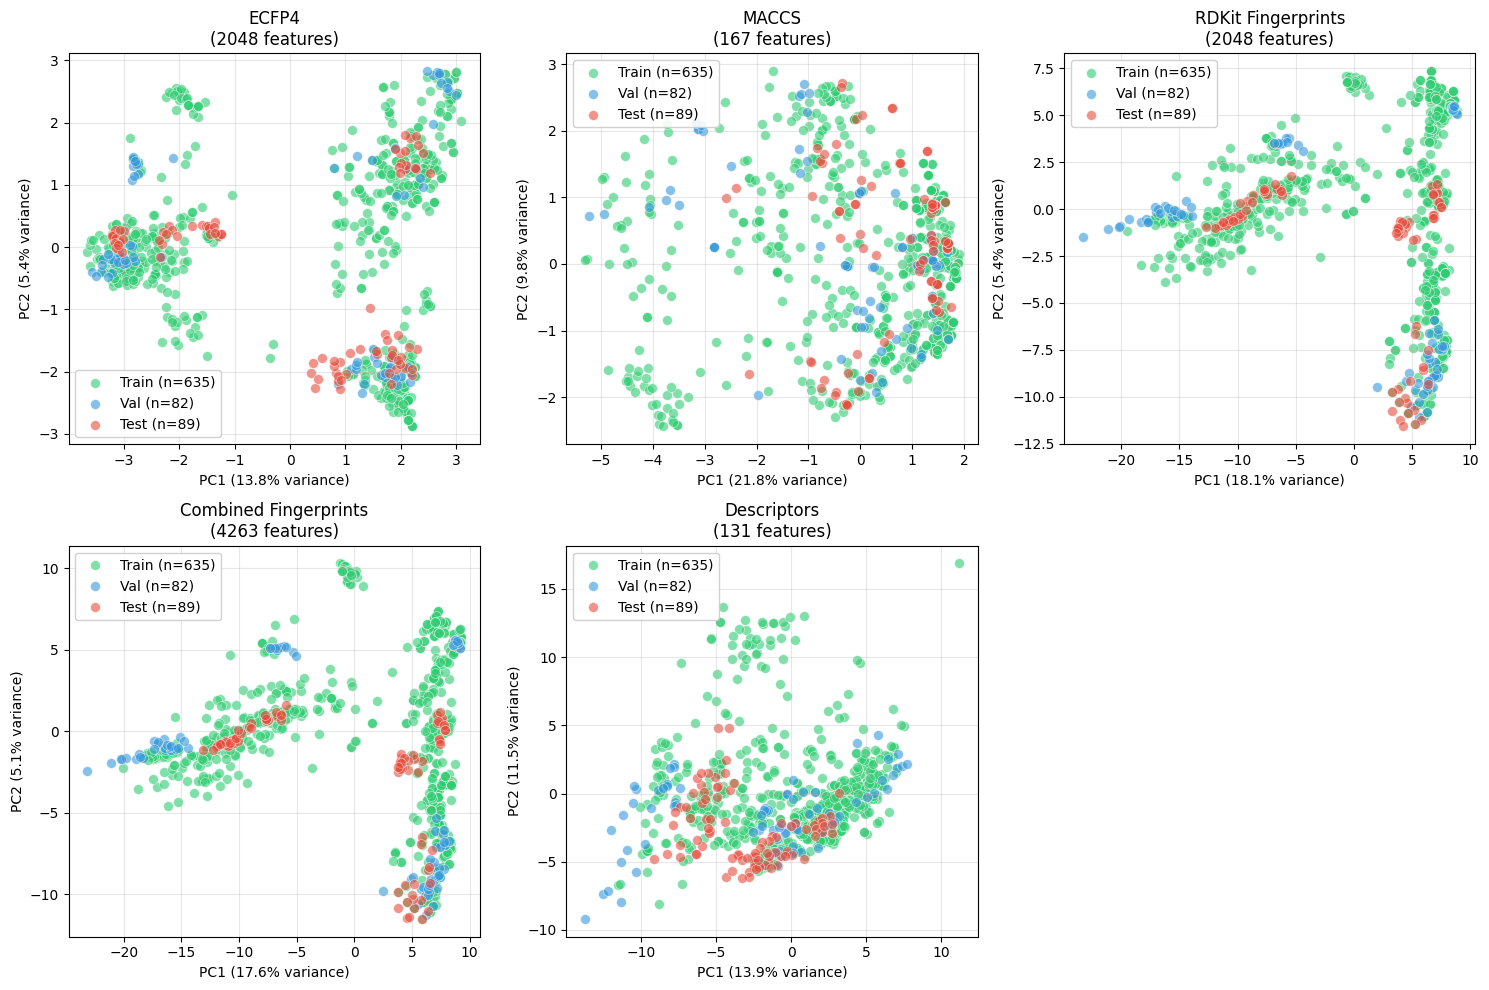

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Define the 5 methods and their file prefixes
methods = {
    'ECFP4': 'DATASET_ecfp4',
    'MACCS': 'DATASET_maccs',
    'RDKit Fingerprints': 'DATASET_rdkit_fp',
    'Combined Fingerprints': 'DATASET_fingerprints_combined',
    'Descriptors': 'DATASET_descriptors'
}

# Columns to exclude (non-feature columns)
EXCLUDE_COLS = ['molecule_chembl_id', 'smiles', 'pIC50']

def detect_feature_columns(df):
    """
    Detect feature columns by excluding specified non-feature columns.
    """
    non_feature_cols = [col for col in df.columns if col in EXCLUDE_COLS]
    feature_cols = [col for col in df.columns if col not in EXCLUDE_COLS]
    return feature_cols, non_feature_cols

def load_splits(file_prefix, splits_dir='splits'):
    """
    Load train, validation, and test splits for a given method.
    """
    train_df = pd.read_csv(f'{splits_dir}/{file_prefix}_train.csv')
    val_df = pd.read_csv(f'{splits_dir}/{file_prefix}_val.csv')
    test_df = pd.read_csv(f'{splits_dir}/{file_prefix}_test.csv')
    return train_df, val_df, test_df

def plot_pca_for_method(method_name, file_prefix, splits_dir='splits', ax=None):
    """
    Perform PCA and plot for train/val/test subsets of a given method.
    """
    # Load data
    train_df, val_df, test_df = load_splits(file_prefix, splits_dir)

    # Detect feature columns
    feature_cols, non_feature_cols = detect_feature_columns(train_df)

    print(f"\n{method_name}:")
    print(f"  Feature columns: {len(feature_cols)}")
    print(f"  Excluded columns: {non_feature_cols}")
    print(f"  Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

    # Extract features
    X_train = train_df[feature_cols].values.astype(float)
    X_val = val_df[feature_cols].values.astype(float)
    X_test = test_df[feature_cols].values.astype(float)

    # Only scale for Descriptors
    if method_name == 'Descriptors':
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_val = scaler.transform(X_val)
        X_test = scaler.transform(X_test)

    # Perform PCA (fit on train, transform all)
    pca = PCA(n_components=2)
    train_pca = pca.fit_transform(X_train)
    val_pca = pca.transform(X_val)
    test_pca = pca.transform(X_test)

    # Get explained variance
    var_explained = pca.explained_variance_ratio_ * 100

    # Plot
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    ax.scatter(train_pca[:, 0], train_pca[:, 1], alpha=0.6, label=f'Train (n={len(train_df)})',
               c='#2ecc71', edgecolors='white', linewidth=0.5, s=50)
    ax.scatter(val_pca[:, 0], val_pca[:, 1], alpha=0.6, label=f'Val (n={len(val_df)})',
               c='#3498db', edgecolors='white', linewidth=0.5, s=50)
    ax.scatter(test_pca[:, 0], test_pca[:, 1], alpha=0.6, label=f'Test (n={len(test_df)})',
               c='#e74c3c', edgecolors='white', linewidth=0.5, s=50)

    ax.set_xlabel(f'PC1 ({var_explained[0]:.1f}% variance)')
    ax.set_ylabel(f'PC2 ({var_explained[1]:.1f}% variance)')
    ax.set_title(f'{method_name}\n({len(feature_cols)} features)')
    ax.legend(loc='best', framealpha=0.9)
    ax.grid(True, alpha=0.3)

    return pca, var_explained

# Main execution
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (method_name, file_prefix) in enumerate(methods.items()):
    plot_pca_for_method(method_name, file_prefix, splits_dir='splits', ax=axes[idx])

# Hide the 6th subplot
axes[5].axis('off')

plt.tight_layout()
plt.show()


#Part 4: Model Development

> **Note:** BRD2 model development follows an abbreviated pipeline
> relative to the primary BRD4 model, reflecting limited training
> data availability (<1000 compounds). Results are intended for
> qualitative selectivity assessment only.

##4.1 Setup and Data Preparation

In [3]:
import numpy as np
import pandas as pd
import io

def upload_and_load_file(var_name, expected_filename=None):
    """
    Prompt user to upload a file and return as DataFrame.
    """
    prompt_msg = f"Please upload the file for '{var_name}'"
    if expected_filename:
        prompt_msg += f" (expected: {expected_filename})"
    prompt_msg += ":"

    # Try Google Colab upload first, fall back to ipywidgets
    try:
        from google.colab import files
        print(prompt_msg)
        uploaded = files.upload()
        filename = list(uploaded.keys())[0]
        file_content = uploaded[filename]
    except ImportError:
        # For Jupyter Notebook
        import ipywidgets as widgets
        from IPython.display import display
        import time

        uploader = widgets.FileUpload(accept='.csv,.xlsx,.xls,.tsv', multiple=False)
        print(prompt_msg)
        display(uploader)

        # Wait for upload
        while not uploader.value:
            time.sleep(0.1)

        filename = list(uploader.value.keys())[0]
        file_content = uploader.value[filename]['content']

    # Read the file based on extension
    if filename.endswith('.csv'):
        df_loaded = pd.read_csv(io.BytesIO(file_content))
    elif filename.endswith(('.xlsx', '.xls')):
        df_loaded = pd.read_excel(io.BytesIO(file_content))
    elif filename.endswith('.tsv'):
        df_loaded = pd.read_csv(io.BytesIO(file_content), sep='\t')
    else:
        df_loaded = pd.read_csv(io.BytesIO(file_content))

    print(f"  ✓ Loaded '{filename}' with {len(df_loaded):,} rows and {len(df_loaded.columns)} columns\n")
    return df_loaded

# Define required datasets with their expected filenames
required_datasets = {
    'train_fp': 'DATASET_ecfp4_train.csv',
    'val_fp': 'DATASET_ecfp4_val.csv',
    'test_fp': 'DATASET_ecfp4_test.csv',
    'train_desc': 'DATASET_descriptors_train.csv',
    'val_desc': 'DATASET_descriptors_val.csv',
    'test_desc': 'DATASET_descriptors_test.csv'
}

# Check each dataframe and prompt for upload if not defined
if 'train_fp' not in dir():
    train_fp = upload_and_load_file('train_fp', required_datasets['train_fp'])

if 'val_fp' not in dir():
    val_fp = upload_and_load_file('val_fp', required_datasets['val_fp'])

if 'test_fp' not in dir():
    test_fp = upload_and_load_file('test_fp', required_datasets['test_fp'])

if 'train_desc' not in dir():
    train_desc = upload_and_load_file('train_desc', required_datasets['train_desc'])

if 'val_desc' not in dir():
    val_desc = upload_and_load_file('val_desc', required_datasets['val_desc'])

if 'test_desc' not in dir():
    test_desc = upload_and_load_file('test_desc', required_datasets['test_desc'])

# Summary of loaded datasets
print("=" * 60)
print("Dataset Summary:")
print("=" * 60)
print(f"  ECFP4 Fingerprints:")
print(f"    train_fp:   {train_fp.shape[0]:,} rows × {train_fp.shape[1]} columns")
print(f"    val_fp:     {val_fp.shape[0]:,} rows × {val_fp.shape[1]} columns")
print(f"    test_fp:    {test_fp.shape[0]:,} rows × {test_fp.shape[1]} columns")
print(f"  Molecular Descriptors:")
print(f"    train_desc: {train_desc.shape[0]:,} rows × {train_desc.shape[1]} columns")
print(f"    val_desc:   {val_desc.shape[0]:,} rows × {val_desc.shape[1]} columns")
print(f"    test_desc:  {test_desc.shape[0]:,} rows × {test_desc.shape[1]} columns")
print("=" * 60)


Please upload the file for 'train_fp' (expected: DATASET_ecfp4_train.csv):


Saving DATASET_ecfp4_train.csv to DATASET_ecfp4_train.csv
  ✓ Loaded 'DATASET_ecfp4_train.csv' with 635 rows and 2051 columns

Please upload the file for 'val_fp' (expected: DATASET_ecfp4_val.csv):


Saving DATASET_ecfp4_val.csv to DATASET_ecfp4_val.csv
  ✓ Loaded 'DATASET_ecfp4_val.csv' with 82 rows and 2051 columns

Please upload the file for 'test_fp' (expected: DATASET_ecfp4_test.csv):


Saving DATASET_ecfp4_test.csv to DATASET_ecfp4_test.csv
  ✓ Loaded 'DATASET_ecfp4_test.csv' with 89 rows and 2051 columns

Please upload the file for 'train_desc' (expected: DATASET_descriptors_train.csv):


Saving DATASET_descriptors_train.csv to DATASET_descriptors_train.csv
  ✓ Loaded 'DATASET_descriptors_train.csv' with 635 rows and 134 columns

Please upload the file for 'val_desc' (expected: DATASET_descriptors_val.csv):


Saving DATASET_descriptors_val.csv to DATASET_descriptors_val.csv
  ✓ Loaded 'DATASET_descriptors_val.csv' with 82 rows and 134 columns

Please upload the file for 'test_desc' (expected: DATASET_descriptors_test.csv):


Saving DATASET_descriptors_test.csv to DATASET_descriptors_test.csv
  ✓ Loaded 'DATASET_descriptors_test.csv' with 89 rows and 134 columns

Dataset Summary:
  ECFP4 Fingerprints:
    train_fp:   635 rows × 2051 columns
    val_fp:     82 rows × 2051 columns
    test_fp:    89 rows × 2051 columns
  Molecular Descriptors:
    train_desc: 635 rows × 134 columns
    val_desc:   82 rows × 134 columns
    test_desc:  89 rows × 134 columns


###4.1.1 Loading Split Datasets

In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print(f"ECFP4 Fingerprints loaded:")
print(f"  Train: {train_fp.shape}")
print(f"  Val:   {val_fp.shape}")
print(f"  Test:  {test_fp.shape}")


ECFP4 Fingerprints loaded:
  Train: (635, 2051)
  Val:   (82, 2051)
  Test:  (89, 2051)


###4.1.2 Preparing Feature Matrices

In [5]:
# Identify metadata and feature columns
metadata_cols = ['molecule_chembl_id', 'smiles', 'pIC50']
feature_cols = [c for c in train_fp.columns if c not in metadata_cols]

print(f"Metadata columns: {len(metadata_cols)}")
print(f"Feature columns: {len(feature_cols)}")

# Extract features and targets for fingerprints
X_train_fp = train_fp[feature_cols].values
X_val_fp = val_fp[feature_cols].values
X_test_fp = test_fp[feature_cols].values

y_train = train_fp['pIC50'].values
y_val = val_fp['pIC50'].values
y_test = test_fp['pIC50'].values

print(f"\nFeature matrix shapes:")
print(f"  X_train: {X_train_fp.shape}")
print(f"  X_val:   {X_val_fp.shape}")
print(f"  X_test:  {X_test_fp.shape}")


Metadata columns: 3
Feature columns: 2048

Feature matrix shapes:
  X_train: (635, 2048)
  X_val:   (82, 2048)
  X_test:  (89, 2048)


###4.1.3 Preparing Descriptor Features

In [6]:
# Get descriptor feature columns
desc_feature_cols = [c for c in train_desc.columns if c not in metadata_cols]
print(f"Descriptor features: {len(desc_feature_cols)}")

# Extract raw features
X_train_desc_raw = train_desc[desc_feature_cols].values
X_val_desc_raw = val_desc[desc_feature_cols].values
X_test_desc_raw = test_desc[desc_feature_cols].values

# Fit scaler on training data ONLY
scaler = StandardScaler()
X_train_desc = scaler.fit_transform(X_train_desc_raw)
X_val_desc = scaler.transform(X_val_desc_raw)  # Transform only, no fit!
X_test_desc = scaler.transform(X_test_desc_raw)  # Transform only, no fit!

print(f"\nDescriptor scaling complete (fit on train only)")
print(f"  Train mean (should be ~0): {X_train_desc.mean():.4f}")
print(f"  Train std (should be ~1): {X_train_desc.std():.4f}")


Descriptor features: 131

Descriptor scaling complete (fit on train only)
  Train mean (should be ~0): 0.0000
  Train std (should be ~1): 1.0000


###4.1.4 Combining Train and Validation for GridSearchCV

In [7]:
# Combine train and validation for GridSearchCV
X_trainval_fp = np.vstack([X_train_fp, X_val_fp])
X_trainval_desc = np.vstack([X_train_desc, X_val_desc])
y_trainval = np.concatenate([y_train, y_val])

print(f"Combined train+val shapes:")
print(f"  Fingerprints: {X_trainval_fp.shape}")
print(f"  Descriptors: {X_trainval_desc.shape}")
print(f"  Target: {y_trainval.shape}")


Combined train+val shapes:
  Fingerprints: (717, 2048)
  Descriptors: (717, 131)
  Target: (717,)


###4.1.5 Evaluation Metrics

In [8]:
def evaluate_model(y_true, y_pred, set_name=''):
    """
    Calculate and display regression metrics.

    Returns dict with R², RMSE, and MAE.
    """
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    metrics = {'R2': r2, 'RMSE': rmse, 'MAE': mae}

    if set_name:
        print(f"{set_name:15} R²={r2:.3f}  RMSE={rmse:.3f}  MAE={mae:.3f}")

    return metrics

# Store all results for comparison
results = {}


##4.2 Baseline Models

###4.2.1 Random Forest Regressor Baseline

In [9]:
from sklearn.ensemble import RandomForestRegressor

# Train Random Forest with default parameters on fingerprints
print("Training Random Forest Baseline (ECFP4 fingerprints)...")
rf_baseline_fp = RandomForestRegressor(
    n_estimators=100,      # Default number of trees
    max_depth=None,        # Grow trees fully
    min_samples_split=2,   # Default
    min_samples_leaf=1,    # Default
    max_features='sqrt',   # Default for regression
    n_jobs=-1,             # Use all CPU cores
    random_state=42
)

rf_baseline_fp.fit(X_trainval_fp, y_trainval)

# Evaluate
print("\nRandom Forest Baseline (ECFP4) Performance:")
results['RF_FP_baseline_trainval'] = evaluate_model(
    y_trainval, rf_baseline_fp.predict(X_trainval_fp), 'Train+Val')
results['RF_FP_baseline_test'] = evaluate_model(
    y_test, rf_baseline_fp.predict(X_test_fp), 'Test')


Training Random Forest Baseline (ECFP4 fingerprints)...

Random Forest Baseline (ECFP4) Performance:
Train+Val       R²=0.909  RMSE=0.300  MAE=0.177
Test            R²=0.540  RMSE=0.386  MAE=0.310


In [10]:
# Train Random Forest baseline on descriptors
print("\nTraining Random Forest Baseline (Descriptors)...")
rf_baseline_desc = RandomForestRegressor(
    n_estimators=100,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42
)

rf_baseline_desc.fit(X_trainval_desc, y_trainval)

print("\nRandom Forest Baseline (Descriptors) Performance:")
results['RF_Desc_baseline_trainval'] = evaluate_model(
    y_trainval, rf_baseline_desc.predict(X_trainval_desc), 'Train+Val')
results['RF_Desc_baseline_test'] = evaluate_model(
    y_test, rf_baseline_desc.predict(X_test_desc), 'Test')



Training Random Forest Baseline (Descriptors)...

Random Forest Baseline (Descriptors) Performance:
Train+Val       R²=0.914  RMSE=0.291  MAE=0.167
Test            R²=0.282  RMSE=0.482  MAE=0.377


###4.2.2 Support Vector Regression Baseline

In [11]:
from sklearn.svm import SVR

# SVR works best with scaled features - use descriptors
print("Training Support Vector Regression Baseline (Descriptors)...")
svr_baseline = SVR(
    kernel='rbf',     # Radial basis function kernel
    C=1.0,            # Default regularization
    epsilon=0.1,      # Default epsilon-tube width
    gamma='scale'     # Default kernel coefficient
)

svr_baseline.fit(X_trainval_desc, y_trainval)

print("\nSVR Baseline (Descriptors) Performance:")
results['SVR_baseline_trainval'] = evaluate_model(
    y_trainval, svr_baseline.predict(X_trainval_desc), 'Train+Val')
results['SVR_baseline_test'] = evaluate_model(
    y_test, svr_baseline.predict(X_test_desc), 'Test')


Training Support Vector Regression Baseline (Descriptors)...

SVR Baseline (Descriptors) Performance:
Train+Val       R²=0.807  RMSE=0.437  MAE=0.241
Test            R²=0.379  RMSE=0.448  MAE=0.342


##4.3 Hyperparameter Optimization with GridSearchCV

###4.3.2 Random Forest Hyperparameter Grid

In [12]:
from sklearn.model_selection import GridSearchCV

# Define Random Forest parameter grid
rf_param_grid = {
    'n_estimators': [100, 200],       # Number of trees
    'max_depth': [10, 20, None],       # Tree depth (None = unlimited)
    'min_samples_split': [2, 5],       # Min samples to split node
    'min_samples_leaf': [1, 3],         # Min samples per leaf
    'max_features': ['sqrt', 'log2']       # Features per split
}

# Calculate total combinations
n_combinations = (len(rf_param_grid['n_estimators']) *
                  len(rf_param_grid['max_depth']) *
                  len(rf_param_grid['min_samples_split']) *
                  len(rf_param_grid['min_samples_leaf']) *
                  len(rf_param_grid['max_features']))

print(f"Random Forest parameter grid:")
for param, values in rf_param_grid.items():
    print(f"  {param}: {values}")
print(f"\nTotal combinations: {n_combinations}")
print(f"Total fits (with 5-fold CV): {n_combinations * 5}")


Random Forest parameter grid:
  n_estimators: [100, 200]
  max_depth: [10, 20, None]
  min_samples_split: [2, 5]
  min_samples_leaf: [1, 3]
  max_features: ['sqrt', 'log2']

Total combinations: 48
Total fits (with 5-fold CV): 240


###4.3.3 Running GridSearchCV for Random Forest

In [13]:
# Run GridSearchCV for Random Forest on fingerprints
print("Running GridSearchCV for Random Forest (ECFP4)...")
print("This may take several minutes.\n")

rf_grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=rf_param_grid,
    cv=5,                              # 5-fold cross-validation
    scoring='neg_mean_squared_error',  # Minimize MSE
    n_jobs=-1,                         # Parallel processing
    return_train_score=True,           # Track overfitting
    verbose=2                          # Show progress
)

rf_grid_search.fit(X_trainval_fp, y_trainval)

print(f"\nBest parameters found:")
for param, value in rf_grid_search.best_params_.items():
    print(f"  {param}: {value}")

# Convert negative MSE to RMSE for interpretability
best_cv_rmse = np.sqrt(-rf_grid_search.best_score_)
print(f"\nBest cross-validation RMSE: {best_cv_rmse:.4f}")


Running GridSearchCV for Random Forest (ECFP4)...
This may take several minutes.

Fitting 5 folds for each of 48 candidates, totalling 240 fits

Best parameters found:
  max_depth: None
  max_features: sqrt
  min_samples_leaf: 1
  min_samples_split: 5
  n_estimators: 200

Best cross-validation RMSE: 0.6558


###4.3.5 Evaluating Optimized Random Forest

In [14]:
# Get the best model (already refitted on full train+val)
rf_optimized = rf_grid_search.best_estimator_

print("Optimized Random Forest (ECFP4) Performance:")
results['RF_FP_optimized_trainval'] = evaluate_model(
    y_trainval, rf_optimized.predict(X_trainval_fp), 'Train+Val')
results['RF_FP_optimized_test'] = evaluate_model(
    y_test, rf_optimized.predict(X_test_fp), 'Test')

# Compare with baseline
baseline_test_r2 = results['RF_FP_baseline_test']['R2']
optimized_test_r2 = results['RF_FP_optimized_test']['R2']
improvement = optimized_test_r2 - baseline_test_r2

print(f"\nImprovement over baseline:")
print(f"  Baseline Test R²:  {baseline_test_r2:.4f}")
print(f"  Optimized Test R²: {optimized_test_r2:.4f}")
print(f"  Improvement:       {improvement:+.4f}")


Optimized Random Forest (ECFP4) Performance:
Train+Val       R²=0.872  RMSE=0.357  MAE=0.231
Test            R²=0.585  RMSE=0.366  MAE=0.298

Improvement over baseline:
  Baseline Test R²:  0.5399
  Optimized Test R²: 0.5852
  Improvement:       +0.0453


##4.4 Support Vector Regression Optimization

###4.4.1 SVR Hyperparameter Grid

In [15]:
# Define SVR parameter grid
svr_param_grid = {
    'C': [0.1, 1.0, 10.0, 100.0],           # Regularization (higher = less regularization)
    'gamma': ['scale', 'auto', 0.01, 0.1],  # Kernel coefficient
    'epsilon': [0.01, 0.1, 0.2, 0.5]        # Epsilon-tube width
}

n_svr_combinations = (len(svr_param_grid['C']) *
                      len(svr_param_grid['gamma']) *
                      len(svr_param_grid['epsilon']))

print(f"SVR parameter grid:")
for param, values in svr_param_grid.items():
    print(f"  {param}: {values}")
print(f"\nTotal combinations: {n_svr_combinations}")
print(f"Total fits (with 5-fold CV): {n_svr_combinations * 5}")


SVR parameter grid:
  C: [0.1, 1.0, 10.0, 100.0]
  gamma: ['scale', 'auto', 0.01, 0.1]
  epsilon: [0.01, 0.1, 0.2, 0.5]

Total combinations: 64
Total fits (with 5-fold CV): 320


###4.4.2 Running GridSearchCV for SVR

In [16]:
# Run GridSearchCV for SVR on descriptors
print("Running GridSearchCV for SVR (Descriptors)...")
print("This may take several minutes.\n")

svr_grid_search = GridSearchCV(
    estimator=SVR(kernel='rbf'),
    param_grid=svr_param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    return_train_score=True,
    verbose=1
)

svr_grid_search.fit(X_trainval_desc, y_trainval)

print(f"\nBest parameters found:")
for param, value in svr_grid_search.best_params_.items():
    print(f"  {param}: {value}")

best_svr_cv_rmse = np.sqrt(-svr_grid_search.best_score_)
print(f"\nBest cross-validation RMSE: {best_svr_cv_rmse:.4f}")


Running GridSearchCV for SVR (Descriptors)...
This may take several minutes.

Fitting 5 folds for each of 64 candidates, totalling 320 fits

Best parameters found:
  C: 1.0
  epsilon: 0.01
  gamma: auto

Best cross-validation RMSE: 0.6824


###4.4.3 Analyzing SVR Results

In [17]:
# Analyze SVR cross-validation results
svr_cv_results = pd.DataFrame(svr_grid_search.cv_results_)
svr_cv_results['mean_cv_rmse'] = np.sqrt(-svr_cv_results['mean_test_score'])
svr_cv_results['std_cv_rmse'] = svr_cv_results['std_test_score'] / (2 * np.sqrt(-svr_cv_results['mean_test_score']))
svr_cv_results['mean_train_rmse'] = np.sqrt(-svr_cv_results['mean_train_score'])

print("Top 10 SVR configurations by CV RMSE:")
print("-" * 80)

top_svr = svr_cv_results.nsmallest(10, 'mean_cv_rmse')[
    ['params', 'mean_cv_rmse', 'std_cv_rmse', 'mean_train_rmse']
]

for idx, row in top_svr.iterrows():
    print(f"CV RMSE: {row['mean_cv_rmse']:.4f} (+/- {row['std_cv_rmse']:.4f})  "
          f"Train RMSE: {row['mean_train_rmse']:.4f}")
    print(f"  Params: {row['params']}")
    print()


Top 10 SVR configurations by CV RMSE:
--------------------------------------------------------------------------------
CV RMSE: 0.6824 (+/- 0.0560)  Train RMSE: 0.4374
  Params: {'C': 1.0, 'epsilon': 0.01, 'gamma': 'auto'}

CV RMSE: 0.6834 (+/- 0.0563)  Train RMSE: 0.4379
  Params: {'C': 1.0, 'epsilon': 0.01, 'gamma': 'scale'}

CV RMSE: 0.6846 (+/- 0.0584)  Train RMSE: 0.4355
  Params: {'C': 1.0, 'epsilon': 0.1, 'gamma': 'auto'}

CV RMSE: 0.6860 (+/- 0.0589)  Train RMSE: 0.4359
  Params: {'C': 1.0, 'epsilon': 0.1, 'gamma': 'scale'}

CV RMSE: 0.6881 (+/- 0.0606)  Train RMSE: 0.4401
  Params: {'C': 1.0, 'epsilon': 0.2, 'gamma': 'auto'}

CV RMSE: 0.6892 (+/- 0.0610)  Train RMSE: 0.4404
  Params: {'C': 1.0, 'epsilon': 0.2, 'gamma': 'scale'}

CV RMSE: 0.6917 (+/- 0.0567)  Train RMSE: 0.4186
  Params: {'C': 1.0, 'epsilon': 0.01, 'gamma': 0.01}

CV RMSE: 0.6936 (+/- 0.0589)  Train RMSE: 0.4167
  Params: {'C': 1.0, 'epsilon': 0.1, 'gamma': 0.01}

CV RMSE: 0.6971 (+/- 0.0598)  Train RMSE: 0.422

###4.4.4 Evaluating Optimized SVR

In [18]:
# Get the best SVR model
svr_optimized = svr_grid_search.best_estimator_

print("Optimized SVR (Descriptors) Performance:")
results['SVR_optimized_trainval'] = evaluate_model(
    y_trainval, svr_optimized.predict(X_trainval_desc), 'Train+Val')
results['SVR_optimized_test'] = evaluate_model(
    y_test, svr_optimized.predict(X_test_desc), 'Test')

# Compare with baseline
svr_baseline_test_r2 = results['SVR_baseline_test']['R2']
svr_optimized_test_r2 = results['SVR_optimized_test']['R2']
svr_improvement = svr_optimized_test_r2 - svr_baseline_test_r2

print(f"\nImprovement over baseline:")
print(f"  Baseline Test R²:  {svr_baseline_test_r2:.4f}")
print(f"  Optimized Test R²: {svr_optimized_test_r2:.4f}")
print(f"  Improvement:       {svr_improvement:+.4f}")


Optimized SVR (Descriptors) Performance:
Train+Val       R²=0.806  RMSE=0.439  MAE=0.216
Test            R²=0.383  RMSE=0.447  MAE=0.340

Improvement over baseline:
  Baseline Test R²:  0.3787
  Optimized Test R²: 0.3827
  Improvement:       +0.0040


##4.5 Model Comparison

###4.5.1 Summary Table

In [19]:
# Create comprehensive summary table
summary_data = []

model_configs = [
    ('Random Forest (FP) - Baseline', 'RF_FP_baseline'),
    ('Random Forest (FP) - Optimized', 'RF_FP_optimized'),
    ('Random Forest (Desc) - Baseline', 'RF_Desc_baseline'),
    ('SVR (Desc) - Baseline', 'SVR_baseline'),
    ('SVR (Desc) - Optimized', 'SVR_optimized'),
]

for name, prefix in model_configs:
    if f'{prefix}_test' in results:
        summary_data.append({
            'Model': name,
            'Train+Val R²': results[f'{prefix}_trainval']['R2'],
            'Test R²': results[f'{prefix}_test']['R2'],
            'Test RMSE': results[f'{prefix}_test']['RMSE'],
            'Test MAE': results[f'{prefix}_test']['MAE'],
        })

df_summary = pd.DataFrame(summary_data)

print("=" * 90)
print("MODEL COMPARISON SUMMARY")
print("=" * 90)
print(df_summary.to_string(index=False))
print("=" * 90)


MODEL COMPARISON SUMMARY
                          Model  Train+Val R²  Test R²  Test RMSE  Test MAE
  Random Forest (FP) - Baseline      0.909277 0.539918   0.385905  0.309508
 Random Forest (FP) - Optimized      0.871549 0.585187   0.366428  0.297564
Random Forest (Desc) - Baseline      0.914287 0.282276   0.481994  0.376764
          SVR (Desc) - Baseline      0.807329 0.378675   0.448458  0.342412
         SVR (Desc) - Optimized      0.805792 0.382697   0.447005  0.340020


###4.5.2 Identifying the Best Model

In [20]:
# Identify best model based on test R²
best_idx = df_summary['Test R²'].idxmax()
best_model_name = df_summary.loc[best_idx, 'Model']
best_test_r2 = df_summary.loc[best_idx, 'Test R²']
best_test_rmse = df_summary.loc[best_idx, 'Test RMSE']

print(f"\nBest performing model: {best_model_name}")
print(f"  Test R²:   {best_test_r2:.4f}")
print(f"  Test RMSE: {best_test_rmse:.4f}")

# Compare Random Forest vs SVR (optimized versions)
rf_opt_r2 = results['RF_FP_optimized_test']['R2']
svr_opt_r2 = results['SVR_optimized_test']['R2']

print(f"\nRandom Forest vs SVR (Optimized):")
print(f"  Random Forest Test R²: {rf_opt_r2:.4f}")
print(f"  SVR Test R²:           {svr_opt_r2:.4f}")

if rf_opt_r2 > svr_opt_r2:
    print(f"  Winner: Random Forest (+{rf_opt_r2 - svr_opt_r2:.4f})")
else:
    print(f"  Winner: SVR (+{svr_opt_r2 - rf_opt_r2:.4f})")



Best performing model: Random Forest (FP) - Optimized
  Test R²:   0.5852
  Test RMSE: 0.3664

Random Forest vs SVR (Optimized):
  Random Forest Test R²: 0.5852
  SVR Test R²:           0.3827
  Winner: Random Forest (+0.2025)


In [25]:
# Assign best model for downstream use
best_model = rf_optimized  # RF wins based on test R²
print(f"\nbest_model assigned: {type(best_model).__name__}")


best_model assigned: RandomForestRegressor


###4.5.3 Saving Comparison Results

In [21]:
# Extract GridSearchCV results as DataFrames
rf_cv_results = pd.DataFrame(rf_grid_search.cv_results_)
svr_cv_results = pd.DataFrame(svr_grid_search.cv_results_)

# Save summary to CSV for publication
df_summary.to_csv('REPORT_model_comparison_summary.csv', index=False)
print("Summary saved to: REPORT_model_comparison_summary.csv")

# Save detailed GridSearchCV results
rf_cv_results.to_csv('REPORT_rf_gridsearch_results.csv', index=False)
svr_cv_results.to_csv('REPORT_svr_gridsearch_results.csv', index=False)
print("GridSearchCV details saved to: REPORT_rf_gridsearch_results.csv, REPORT_svr_gridsearch_results.csv")


Summary saved to: REPORT_model_comparison_summary.csv
GridSearchCV details saved to: REPORT_rf_gridsearch_results.csv, REPORT_svr_gridsearch_results.csv


##4.6 Saving Trained Models

In [22]:
import joblib
import os

# Create models directory
os.makedirs('models', exist_ok=True)

# Save Random Forest models
joblib.dump(rf_baseline_fp, 'models/rf_baseline_fingerprints.joblib')
joblib.dump(rf_baseline_desc, 'models/rf_baseline_descriptors.joblib')
joblib.dump(rf_optimized, 'models/rf_optimized_fingerprints.joblib')

# Save SVR models
joblib.dump(svr_baseline, 'models/svr_baseline_descriptors.joblib')
joblib.dump(svr_optimized, 'models/svr_optimized_descriptors.joblib')

# Save the descriptor scaler (critical for deployment)
joblib.dump(scaler, 'models/descriptor_scaler.joblib')

# Save GridSearchCV objects (contains full search history)
joblib.dump(rf_grid_search, 'models/rf_gridsearch_cv.joblib')
joblib.dump(svr_grid_search, 'models/svr_gridsearch_cv.joblib')

print("All models saved to 'models/' directory:")
for f in sorted(os.listdir('models')):
    print(f"  {f}")


All models saved to 'models/' directory:
  descriptor_scaler.joblib
  rf_baseline_descriptors.joblib
  rf_baseline_fingerprints.joblib
  rf_gridsearch_cv.joblib
  rf_optimized_fingerprints.joblib
  svr_baseline_descriptors.joblib
  svr_gridsearch_cv.joblib
  svr_optimized_descriptors.joblib


###4.6.1 Saving Best Model Parameters

In [23]:
import json

# Compile best parameters
best_params_summary = {
    'random_forest_optimized': {
        'representation': 'ECFP4 fingerprints (2048 bits)',
        'parameters': rf_grid_search.best_params_,
        'cv_rmse': float(np.sqrt(-rf_grid_search.best_score_)),
        'test_r2': float(results['RF_FP_optimized_test']['R2']),
        'test_rmse': float(results['RF_FP_optimized_test']['RMSE'])
    },
    'svr_optimized': {
        'representation': 'RDKit descriptors (scaled)',
        'parameters': svr_grid_search.best_params_,
        'cv_rmse': float(np.sqrt(-svr_grid_search.best_score_)),
        'test_r2': float(results['SVR_optimized_test']['R2']),
        'test_rmse': float(results['SVR_optimized_test']['RMSE'])
    }
}

# Save as JSON
with open('models/best_parameters.json', 'w') as f:
    json.dump(best_params_summary, f, indent=2)

print("Best parameters saved to: models/best_parameters.json")
print("\nContents:")
print(json.dumps(best_params_summary, indent=2))


Best parameters saved to: models/best_parameters.json

Contents:
{
  "random_forest_optimized": {
    "representation": "ECFP4 fingerprints (2048 bits)",
    "parameters": {
      "max_depth": null,
      "max_features": "sqrt",
      "min_samples_leaf": 1,
      "min_samples_split": 5,
      "n_estimators": 200
    },
    "cv_rmse": 0.6557987306842747,
    "test_r2": 0.5851867598173595,
    "test_rmse": 0.3664282514055161
  },
  "svr_optimized": {
    "representation": "RDKit descriptors (scaled)",
    "parameters": {
      "C": 1.0,
      "epsilon": 0.01,
      "gamma": "auto"
    },
    "cv_rmse": 0.6823768300609154,
    "test_r2": 0.3826967746680877,
    "test_rmse": 0.4470045236989534
  }
}


In [56]:
# Assign best model and feature matrices for Part 5
best_model = rf_optimized

X_train = X_train_fp
X_val   = X_val_fp
X_test  = X_test_fp
X_trainval = X_trainval_fp

# train_smiles / test_smiles for Part 6
train_smiles = train_fp['smiles'].values
test_smiles  = test_fp['smiles'].values

# Generate test set predictions for Part 5 validation
y_pred_test = best_model.predict(X_test)
print(f"y_pred_test ready: {len(y_pred_test)} compounds")
print(f"X_test shape: {X_test.shape}")

y_pred_test ready: 89 compounds
X_test shape: (89, 2048)


In [57]:
# Generate test set predictions for Part 5 validation
y_pred_test = best_model.predict(X_test)
print(f"y_pred_test ready: {len(y_pred_test)} compounds")

y_pred_test ready: 89 compounds


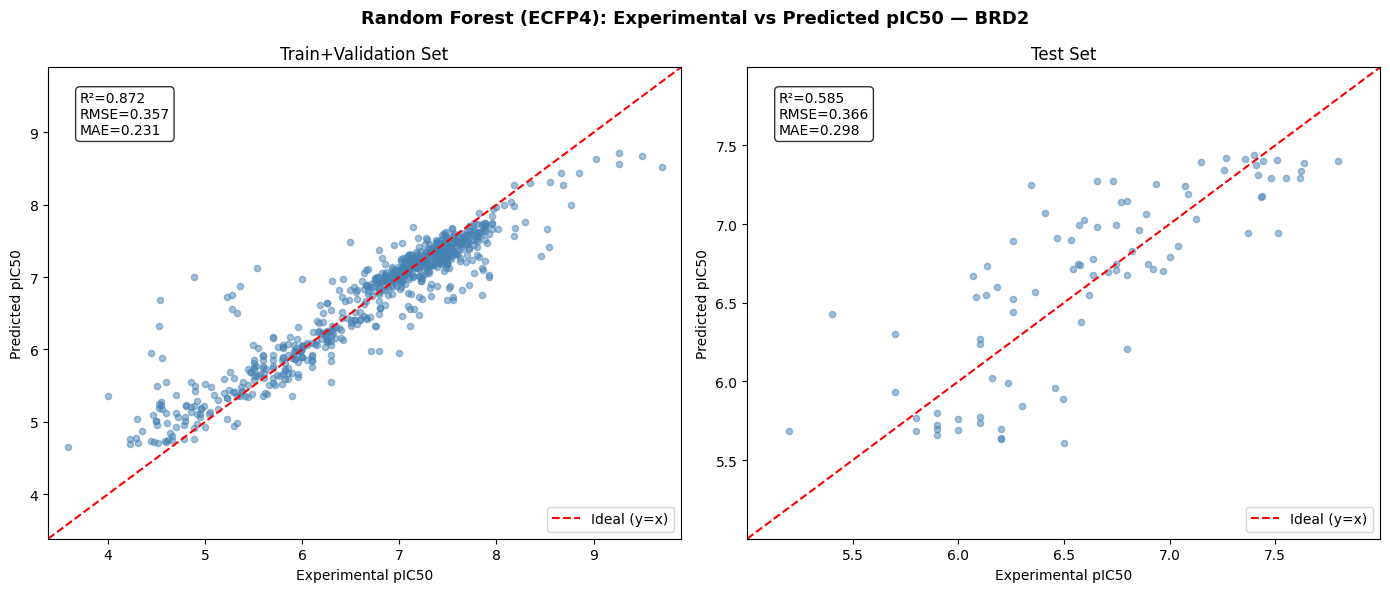

Figure saved: REPORT_brd2_experimental_vs_predicted.png


In [58]:
# ── Experimental vs Predicted pIC50 (BRD2) ───────────────────────────────
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Random Forest (ECFP4): Experimental vs Predicted pIC50 — BRD2',
             fontsize=13, fontweight='bold')

datasets = [
    (np.concatenate([y_train, y_val]),
     best_model.predict(np.vstack([X_train, X_val])),
     'Train+Validation Set'),
    (y_test,
     best_model.predict(X_test),
     'Test Set'),
]

for ax, (y_true, y_pred, title) in zip(axes, datasets):
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)

    ax.scatter(y_true, y_pred, alpha=0.5, s=20, color='steelblue')

    lims = [min(y_true.min(), y_pred.min()) - 0.2,
            max(y_true.max(), y_pred.max()) + 0.2]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Ideal (y=x)')

    ax.text(0.05, 0.95,
            f'R²={r2:.3f}\nRMSE={rmse:.3f}\nMAE={mae:.3f}',
            transform=ax.transAxes, fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    ax.set_xlabel('Experimental pIC50')
    ax.set_ylabel('Predicted pIC50')
    ax.set_title(title)
    ax.legend(loc='lower right')
    ax.set_xlim(lims); ax.set_ylim(lims)

plt.tight_layout()
plt.savefig('REPORT_brd2_experimental_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: REPORT_brd2_experimental_vs_predicted.png")

#Part 5: Rigorous Validation

##5.1 Validation Overview

In [59]:
# All variables already in memory from Part 4:
#   best_model, X_train, X_val, X_test, y_train, y_val, y_test
#   X_trainval, y_trainval

from scipy import stats
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Generate test set predictions
y_pred_test = best_model.predict(X_test)

print("=" * 60)
print("PART 5: RIGOROUS VALIDATION")
print("=" * 60)
print("Note: BRD2 model is used as qualitative selectivity filter.")
print("Final candidate selection is based on docking score differentials.")
print()
print(f"Model:   {type(best_model).__name__}")
print(f"Test:    {len(y_test):,} compounds  |  Features: {X_test.shape[1]} ECFP4 bits")

PART 5: RIGOROUS VALIDATION
Note: BRD2 model is used as qualitative selectivity filter.
Final candidate selection is based on docking score differentials.

Model:   RandomForestRegressor
Test:    89 compounds  |  Features: 2048 ECFP4 bits


##5.2 Golbraikh-Tropsha Criteria

In [60]:
# ── 5.2 Golbraikh-Tropsha Criteria ────────────────────────────────────────
def golbraikh_tropsha_criteria(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)

    k       = np.sum(y_true * y_pred) / np.sum(y_pred ** 2)
    k_prime = np.sum(y_true * y_pred) / np.sum(y_true ** 2)

    y_pred_scaled = k * y_pred
    r0_sq = 1 - np.sum((y_true - y_pred_scaled)**2) / np.sum((y_true - np.mean(y_true))**2)

    y_true_scaled = k_prime * y_true
    r0_prime_sq = 1 - np.sum((y_pred - y_true_scaled)**2) / np.sum((y_pred - np.mean(y_pred))**2)

    return {
        'r2':          r2,
        'r0_sq':       r0_sq,
        'r0_prime_sq': r0_prime_sq,
        'k':           k,
        'k_prime':     k_prime,
        'criterion_1': r2 > 0.6,
        'criterion_2': (abs(r2 - r0_sq) < 0.1) or (abs(r2 - r0_prime_sq) < 0.1),
        'criterion_3': (0.85 <= k <= 1.15) or (0.85 <= k_prime <= 1.15),
        'criterion_4': abs(r0_sq - r0_prime_sq) < 0.3
    }

gt = golbraikh_tropsha_criteria(y_test, y_pred_test)

print("GOLBRAIKH-TROPSHA VALIDATION CRITERIA")
print("=" * 50)
print(f"r²:       {gt['r2']:.4f}")
print(f"r0²:      {gt['r0_sq']:.4f}")
print(f"r'0²:     {gt['r0_prime_sq']:.4f}")
print(f"k:        {gt['k']:.4f}")
print(f"k':       {gt['k_prime']:.4f}")
print()
print(f"  1. r² > 0.6:                         {'PASS' if gt['criterion_1'] else 'FAIL'}")
print(f"  2. |r² - r0²| or |r² - r'0²| < 0.1: {'PASS' if gt['criterion_2'] else 'FAIL'}")
print(f"  3. 0.85 ≤ k or k' ≤ 1.15:           {'PASS' if gt['criterion_3'] else 'FAIL'}")
print(f"  4. |r0² - r'0²| < 0.3:              {'PASS' if gt['criterion_4'] else 'FAIL'}")

all_pass = all([gt['criterion_1'], gt['criterion_2'], gt['criterion_3'], gt['criterion_4']])
print(f"\n{'[PASS] All criteria satisfied.' if all_pass else '[WARNING] One or more criteria failed.'}")

GOLBRAIKH-TROPSHA VALIDATION CRITERIA
r²:       0.5852
r0²:      0.5887
r'0²:     0.6015
k:        0.9949
k':       1.0021

  1. r² > 0.6:                         FAIL
  2. |r² - r0²| or |r² - r'0²| < 0.1: PASS
  3. 0.85 ≤ k or k' ≤ 1.15:           PASS
  4. |r0² - r'0²| < 0.3:              PASS

[WARNING] One or more criteria failed.


##5.3 Y-Randomization Test

###5.3.1 Run Y-Randomization

In [61]:
def y_randomization_test(X, y, model_class, model_params, n_iterations=30, cv=5):
    np.random.seed(42)

    original_model = model_class(**model_params)
    original_r2    = cross_val_score(original_model, X, y, cv=cv, scoring='r2').mean()

    randomized_r2s = []
    for i in range(n_iterations):
        y_shuffled = np.random.permutation(y)
        model      = model_class(**model_params)
        score      = cross_val_score(model, X, y_shuffled, cv=cv, scoring='r2').mean()
        randomized_r2s.append(score)
        if (i + 1) % 10 == 0:
            print(f"  {i+1}/{n_iterations} iterations done...")

    return {
        'original_r2':     original_r2,
        'randomized_r2s':  randomized_r2s,
        'randomized_mean': np.mean(randomized_r2s),
        'randomized_std':  np.std(randomized_r2s),
    }

rf_params = {
    'n_estimators':      best_model.n_estimators,
    'max_depth':         best_model.max_depth,
    'min_samples_split': best_model.min_samples_split,
    'min_samples_leaf':  best_model.min_samples_leaf,
    'max_features':      best_model.max_features,
    'random_state':      42,
    'n_jobs':            -1
}

# n_iterations=30: sufficient given expected z-score >> 3
# Consistent with Tropsha et al. (2010) recommendation of >=20-30 iterations
print("Running Y-randomization test (30 iterations)...\n")
y_rand = y_randomization_test(
    X_trainval, y_trainval,
    RandomForestRegressor, rf_params,
    n_iterations=30
)

Running Y-randomization test (30 iterations)...

  10/30 iterations done...
  20/30 iterations done...
  30/30 iterations done...


###5.3.2 Results & Plot

Original R² (5-fold CV): 0.5293
Randomized R² mean:      -0.1053 ± 0.0278
Z-score:                 22.83
p-value:                 0.0000

[PASS] Model significantly outperforms random (z > 3)
  The model has learned genuine structure-activity relationships.


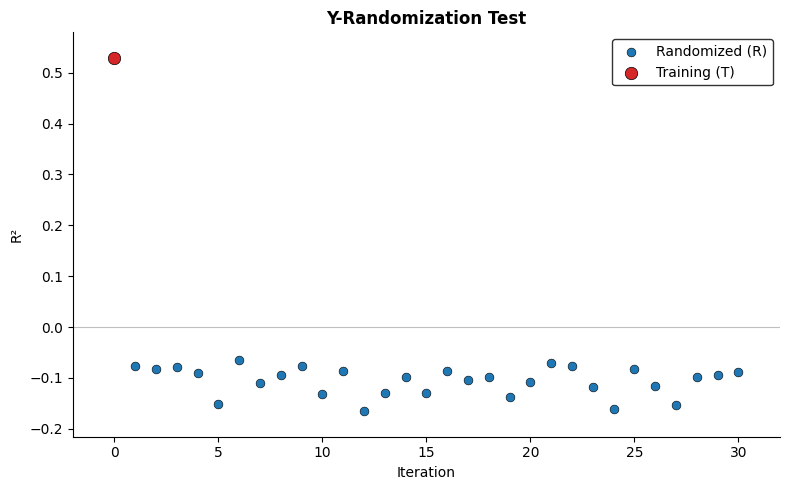

In [62]:
z_score = (y_rand['original_r2'] - y_rand['randomized_mean']) / y_rand['randomized_std']
n_exceed = sum(r >= y_rand['original_r2'] for r in y_rand['randomized_r2s'])
p_value  = n_exceed / len(y_rand['randomized_r2s'])
randomized_max = max(y_rand['randomized_r2s'])

print(f"Original R² (5-fold CV): {y_rand['original_r2']:.4f}")
print(f"Randomized R² mean:      {y_rand['randomized_mean']:.4f} ± {y_rand['randomized_std']:.4f}")
print(f"Z-score:                 {z_score:.2f}")
print(f"p-value:                 {p_value:.4f}")

if z_score > 3 and randomized_max < y_rand['original_r2']:
    print(f"\n[PASS] Model significantly outperforms random (z > 3)")
    print(f"  The model has learned genuine structure-activity relationships.")
else:
    print(f"\n[WARNING] Model may be exploiting chance correlations")
    print(f"  Review your data and model for potential issues.")

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(range(1, len(y_rand['randomized_r2s']) + 1), y_rand['randomized_r2s'],
           color='#1f77b4', s=40, edgecolor='black', linewidth=0.4,
           label='Randomized (R)', zorder=3)
ax.scatter(0, y_rand['original_r2'], color='#d62728', s=80,
           edgecolor='black', linewidth=0.5,
           label='Training (T)', zorder=4)
ax.axhline(0, color='gray', linewidth=0.8, alpha=0.5)
ax.set_xlim(-2, len(y_rand['randomized_r2s']) + 2)
ax.set_ylim(min(y_rand['randomized_r2s']) - 0.05, y_rand['original_r2'] + 0.05)
ax.set_xlabel('Iteration')
ax.set_ylabel('R²')
ax.set_title('Y-Randomization Test', fontweight='bold')
ax.legend(frameon=True, edgecolor='black')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('REPORT_y_randomization_brd2.png', dpi=150, bbox_inches='tight')
plt.show()

##5.4 Bootstrap Confidence Intervals

In [63]:
def bootstrap_ci(y_true, y_pred, n_bootstrap=1000, ci=95):
    np.random.seed(42)
    n = len(y_true)
    metrics = {'R2': [], 'RMSE': [], 'MAE': []}

    for _ in range(n_bootstrap):
        idx = np.random.choice(n, size=n, replace=True)
        yt, yp = y_true[idx], y_pred[idx]
        metrics['R2'].append(r2_score(yt, yp))
        metrics['RMSE'].append(np.sqrt(mean_squared_error(yt, yp)))
        metrics['MAE'].append(mean_absolute_error(yt, yp))

    alpha = (100 - ci) / 2
    return {m: {'mean':     np.mean(v),
                'ci_lower': np.percentile(v, alpha),
                'ci_upper': np.percentile(v, 100 - alpha)}
            for m, v in metrics.items()}

print("Calculating bootstrap confidence intervals (1000 iterations)...")
boot = bootstrap_ci(y_test, y_pred_test)

print("\nBOOTSTRAP 95% CONFIDENCE INTERVALS")
print("=" * 55)
print(f"{'Metric':<10} {'Mean':>10} {'CI Lower':>12} {'CI Upper':>12}")
print("-" * 55)
for m in ['R2', 'RMSE', 'MAE']:
    d = boot[m]
    print(f"{m:<10} {d['mean']:>10.4f} {d['ci_lower']:>12.4f} {d['ci_upper']:>12.4f}")
print("=" * 55)

Calculating bootstrap confidence intervals (1000 iterations)...

BOOTSTRAP 95% CONFIDENCE INTERVALS
Metric           Mean     CI Lower     CI Upper
-------------------------------------------------------
R2             0.5730       0.3977       0.7057
RMSE           0.3661       0.3158       0.4175
MAE            0.2979       0.2564       0.3425


##5.5 Validation Summary Report

In [64]:
print("=" * 70)
print("QSAR MODEL VALIDATION REPORT — BRD2")
print("=" * 70)
print(f"Model:    Random Forest (ECFP4 fingerprints)")
print(f"Target:   BRD2 pIC50")
print(f"Date:     {pd.Timestamp.now().strftime('%Y-%m-%d')}")
print()
print("DATASET SUMMARY")
print("-" * 70)
print(f"Training set:   {len(y_train):>6,} compounds")
print(f"Validation set: {len(y_val):>6,} compounds")
print(f"Test set:       {len(y_test):>6,} compounds")
print()
print("EXTERNAL TEST SET (95% bootstrap CI)")
print("-" * 70)
for m in ['R2', 'RMSE', 'MAE']:
    d = boot[m]
    print(f"  {m:<6} {d['mean']:.4f}  [{d['ci_lower']:.4f} – {d['ci_upper']:.4f}]")
print()
print("Y-RANDOMIZATION")
print("-" * 70)
print(f"  Z-score: {z_score:.2f}   p-value: {p_value:.4f}   {'PASS' if z_score > 3 else 'FAIL'}")
print()
print("GOLBRAIKH-TROPSHA")
print("-" * 70)
for name, result in zip(
    ["r² > 0.6", "|r²−r0²| < 0.1", "0.85 ≤ k ≤ 1.15", "|r0²−r'0²| < 0.3"],
    [gt['criterion_1'], gt['criterion_2'], gt['criterion_3'], gt['criterion_4']]
):
    print(f"  {name:<30} {'PASS' if result else 'FAIL'}")
print("=" * 70)
print()
print("NOTE: Model performance (R²=0.585) is limited by training set")
print("size (<1000 compounds). Predictions are used as qualitative")
print("selectivity filter alongside BRD4/BRD2 docking score differentials.")

# Save
lines = [
    "QSAR MODEL VALIDATION REPORT — BRD2",
    f"Model: Random Forest (ECFP4)  |  Date: {pd.Timestamp.now().strftime('%Y-%m-%d')}",
    "",
    f"Test R²:   {boot['R2']['mean']:.4f} [{boot['R2']['ci_lower']:.4f}–{boot['R2']['ci_upper']:.4f}]",
    f"Test RMSE: {boot['RMSE']['mean']:.4f} [{boot['RMSE']['ci_lower']:.4f}–{boot['RMSE']['ci_upper']:.4f}]",
    f"Test MAE:  {boot['MAE']['mean']:.4f} [{boot['MAE']['ci_lower']:.4f}–{boot['MAE']['ci_upper']:.4f}]",
    f"Y-rand Z:  {z_score:.2f}  (p={p_value:.4f})  {'PASS' if z_score > 3 else 'FAIL'}",
    f"GT criteria: {'PASS' if all_pass else 'FAIL'}",
    "",
    "NOTE: Model is used as qualitative selectivity filter only.",
]
with open('REPORT_validation_report_brd2.txt', 'w') as f:
    f.write('\n'.join(lines))
print("\nSaved: REPORT_validation_report_brd2.txt")

QSAR MODEL VALIDATION REPORT — BRD2
Model:    Random Forest (ECFP4 fingerprints)
Target:   BRD2 pIC50
Date:     2026-04-04

DATASET SUMMARY
----------------------------------------------------------------------
Training set:      635 compounds
Validation set:     82 compounds
Test set:           89 compounds

EXTERNAL TEST SET (95% bootstrap CI)
----------------------------------------------------------------------
  R2     0.5730  [0.3977 – 0.7057]
  RMSE   0.3661  [0.3158 – 0.4175]
  MAE    0.2979  [0.2564 – 0.3425]

Y-RANDOMIZATION
----------------------------------------------------------------------
  Z-score: 22.83   p-value: 0.0000   PASS

GOLBRAIKH-TROPSHA
----------------------------------------------------------------------
  r² > 0.6                       FAIL
  |r²−r0²| < 0.1                 PASS
  0.85 ≤ k ≤ 1.15                PASS
  |r0²−r'0²| < 0.3               PASS

NOTE: Model performance (R²=0.585) is limited by training set
size (<1000 compounds). Predictions are u

> Model performance (R²=0.585) is limited by training set size.
> Predictions are used as qualitative selectivity filter alongside
> BRD4/BRD2 docking score differentials.

#Part 6: Model Interpretation & Applicability Domain

##6.1 Setup and Data Loading

In [65]:
import numpy as np
import pandas as pd
import joblib
import io

def upload_and_load_file(var_name, expected_filename=None, file_type='csv'):
    """
    Prompt user to upload a file and return as DataFrame or model.
    """
    prompt_msg = f"Please upload the file for '{var_name}'"
    if expected_filename:
        prompt_msg += f" (expected: {expected_filename})"
    prompt_msg += ":"

    if file_type == 'joblib':
        accept_types = '.joblib,.pkl,.pickle'
    else:
        accept_types = '.csv,.xlsx,.xls,.tsv'

    try:
        from google.colab import files
        print(prompt_msg)
        uploaded = files.upload()
        filename = list(uploaded.keys())[0]
        file_content = uploaded[filename]
    except ImportError:
        import ipywidgets as widgets
        from IPython.display import display
        import time

        uploader = widgets.FileUpload(accept=accept_types, multiple=False)
        print(prompt_msg)
        display(uploader)

        while not uploader.value:
            time.sleep(0.1)

        filename = list(uploader.value.keys())[0]
        file_content = uploader.value[filename]['content']

    if file_type == 'joblib' or filename.endswith(('.joblib', '.pkl', '.pickle')):
        loaded_obj = joblib.load(io.BytesIO(file_content))
        print(f"  ✓ Loaded model '{filename}' (type: {type(loaded_obj).__name__})\n")
        return loaded_obj
    elif filename.endswith('.csv'):
        df_loaded = pd.read_csv(io.BytesIO(file_content))
    elif filename.endswith(('.xlsx', '.xls')):
        df_loaded = pd.read_excel(io.BytesIO(file_content))
    elif filename.endswith('.tsv'):
        df_loaded = pd.read_csv(io.BytesIO(file_content), sep='\t')
    else:
        df_loaded = pd.read_csv(io.BytesIO(file_content))

    print(f"  ✓ Loaded '{filename}' with {len(df_loaded):,} rows and {len(df_loaded.columns)} columns\n")
    return df_loaded

# --- Check and load each required file ---
required_files = {
    'train_fp':   {'filename': 'DATASET_ecfp4_train.csv',      'type': 'csv'},
    'val_fp':     {'filename': 'DATASET_ecfp4_val.csv',        'type': 'csv'},
    'test_fp':    {'filename': 'DATASET_ecfp4_test.csv',       'type': 'csv'},
    'best_model': {'filename': 'rf_baseline_fingerprints.joblib', 'type': 'joblib'}
}

for var_name, info in required_files.items():
    if var_name not in globals() or globals()[var_name] is None:
        globals()[var_name] = upload_and_load_file(var_name, info['filename'], info['type'])

# Assign to local names for convenience
train_fp   = globals()['train_fp']
val_fp     = globals()['val_fp']
test_fp    = globals()['test_fp']
best_model = globals()['best_model']

# Summary
print("=" * 60)
print("Loaded Files Summary:")
print("=" * 60)
print(f"  train_fp:   {len(train_fp):,} rows × {len(train_fp.columns)} columns")
print(f"  val_fp:     {len(val_fp):,} rows × {len(val_fp.columns)} columns")
print(f"  test_fp:    {len(test_fp):,} rows × {len(test_fp.columns)} columns")
print(f"  best_model: {type(best_model).__name__}")
print("=" * 60)


Loaded Files Summary:
  train_fp:   635 rows × 2051 columns
  val_fp:     82 rows × 2051 columns
  test_fp:    89 rows × 2051 columns
  best_model: RandomForestRegressor


In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Load the best model: Random Forest (Fingerprints) - Baseline
print(f"Loaded model: Random Forest (Fingerprints) - Baseline")
print(f"Number of estimators: {best_model.n_estimators}")


# Prepare feature matrices
metadata_cols = ['molecule_chembl_id', 'smiles', 'pIC50']
feature_cols = [c for c in train_fp.columns if c not in metadata_cols]

X_train = train_fp[feature_cols].values
X_val = val_fp[feature_cols].values
X_test = test_fp[feature_cols].values

y_train = train_fp['pIC50'].values
y_val = val_fp['pIC50'].values
y_test = test_fp['pIC50'].values

# Store SMILES for later use
train_smiles = train_fp['smiles'].values
test_smiles = test_fp['smiles'].values

print(f"\nDatasets loaded:")
print(f"  Train: {len(y_train):,} compounds")
print(f"  Test:  {len(y_test):,} compounds")
print(f"  Features: {len(feature_cols)} ECFP4 bits")


Loaded model: Random Forest (Fingerprints) - Baseline
Number of estimators: 200

Datasets loaded:
  Train: 635 compounds
  Test:  89 compounds
  Features: 2048 ECFP4 bits


##6.2 SHAP Analysis for Feature Importance

###6.2.1 Computing SHAP Values

In [ ]:
!pip install shap -q
import shap

# Initialize SHAP TreeExplainer for Random Forest
# TreeExplainer is optimized for tree-based models like Random Forest
print("Initializing SHAP TreeExplainer for Random Forest...")
explainer = shap.TreeExplainer(best_model, X_train, feature_perturbation='interventional')
shap_values_test = explainer.shap_values(X_test)

print(f"SHAP values computed. Shape: {shap_values_test.shape}")
# Compute SHAP values for test set
# This may take a while for large datasets
print("Computing SHAP values for test set...")
shap_values_test = explainer.shap_values(X_test)

print(f"SHAP values computed.")
print(f"  Shape: {shap_values_test.shape}")
print(f"  (n_samples, n_features) = ({X_test.shape[0]}, {X_test.shape[1]})")


Initializing SHAP TreeExplainer for Random Forest...
SHAP values computed. Shape: (89, 2048)
Computing SHAP values for test set...
SHAP values computed.
  Shape: (89, 2048)
  (n_samples, n_features) = (89, 2048)


In [ ]:
# Also compute SHAP values for training set (for global importance)
print("Computing SHAP values for training set (for global analysis)...")

# Use a subset if training set is very large
if len(X_train) > 1000:
    np.random.seed(42)
    sample_idx = np.random.choice(len(X_train), 1000, replace=False)
    X_train_sample = X_train[sample_idx]
    print(f"  Using random sample of 1000 training compounds")
else:
    X_train_sample = X_train
    print(f"  Using all {len(X_train)} training compounds")

shap_values_train = explainer.shap_values(X_train_sample)
print(f"SHAP values computed for training sample.")


Computing SHAP values for training set (for global analysis)...
  Using all 635 training compounds


 97%|=================== | 614/635 [00:56<00:01]       

SHAP values computed for training sample.


###6.2.2 Global Feature Importance

In [ ]:
# Calculate mean absolute SHAP value for each feature
mean_shap_importance = np.abs(shap_values_train).mean(axis=0)

# Create DataFrame of feature importance
feature_importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': mean_shap_importance
}).sort_values('importance', ascending=False)

print("TOP 20 MOST IMPORTANT FEATURES (by mean |SHAP|)")
print("Model: Random Forest (FP) Baseline")
print("=" * 50)
print(f"{'Rank':<6} {'Feature':<20} {'Mean |SHAP|':>12}")
print("-" * 50)

for i, (_, row) in enumerate(feature_importance_df.head(20).iterrows()):
    print(f"{i+1:<6} {row['feature']:<20} {row['importance']:>12.4f}")

print("=" * 50)


TOP 20 MOST IMPORTANT FEATURES (by mean |SHAP|)
Model: Random Forest (FP) Baseline
Rank   Feature               Mean |SHAP|
--------------------------------------------------
1      ECFP4_816                  0.0515
2      ECFP4_561                  0.0452
3      ECFP4_1683                 0.0425
4      ECFP4_1070                 0.0393
5      ECFP4_1164                 0.0357
6      ECFP4_216                  0.0345
7      ECFP4_1427                 0.0288
8      ECFP4_1283                 0.0270
9      ECFP4_1803                 0.0254
10     ECFP4_873                  0.0243
11     ECFP4_1391                 0.0218
12     ECFP4_1279                 0.0208
13     ECFP4_1019                 0.0171
14     ECFP4_1922                 0.0137
15     ECFP4_1825                 0.0126
16     ECFP4_1450                 0.0119
17     ECFP4_395                  0.0117
18     ECFP4_879                  0.0105
19     ECFP4_1658                 0.0103
20     ECFP4_464                  0.0095


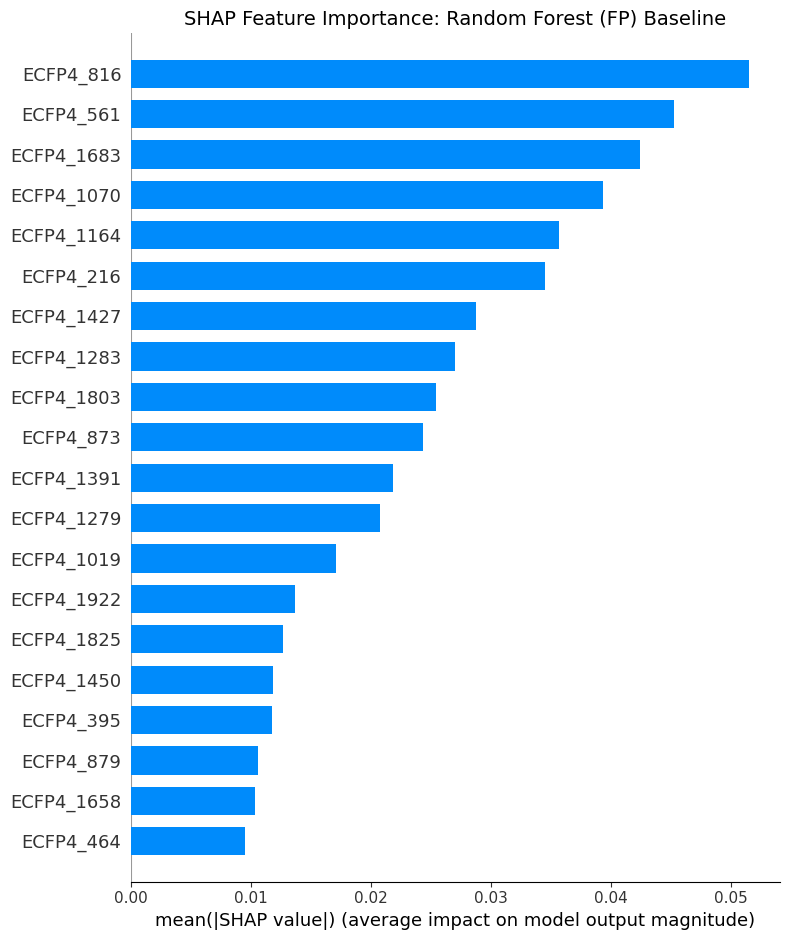

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 8))
shap.summary_plot(
    shap_values_train,
    X_train_sample,
    feature_names=feature_cols,
    max_display=20,
    plot_type="bar",   # single aggregated bar plot across all classes
    show=False
)
plt.title('SHAP Feature Importance: Random Forest (FP) Baseline', fontsize=14)
plt.tight_layout()
plt.savefig('shap_summary_plot.png', dpi=150, bbox_inches='tight')
plt.show()


###6.2.3 Mapping SHAP to Chemical Substructures

In [ ]:
!pip install rdkit -q
from rdkit import Chem
from rdkit.Chem import AllChem, Draw
from collections import defaultdict
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

def get_ecfp_bit_info(smiles_list, radius=2, n_bits=2048):
    """
    Extract bit information for ECFP fingerprints.
    Returns a mapping of bit index to (SMILES, atom_idx, radius) tuples.
    """
    bit_info_all = defaultdict(list)

    for smiles in smiles_list[:100]:  # Sample for efficiency
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            continue

        bit_info = {}
        fp = AllChem.GetMorganFingerprintAsBitVect(
            mol, radius=radius, nBits=n_bits, bitInfo=bit_info
        )

        for bit_idx, atoms_radii in bit_info.items():
            for atom_idx, rad in atoms_radii:
                bit_info_all[bit_idx].append((smiles, atom_idx, rad))

    return bit_info_all

# Get bit information from training compounds
print("Extracting ECFP bit information from training compounds...")
bit_info = get_ecfp_bit_info(train_smiles.tolist())
print(f"Mapped {len(bit_info)} unique bits to molecular substructures.")


Extracting ECFP bit information from training compounds...
Mapped 932 unique bits to molecular substructures.


In [ ]:
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import display, HTML
import io

def visualize_bit_substructure(bit_idx, bit_info_dict):
    if bit_idx not in bit_info_dict:
        return None, None, None, None, None

    for smi, atom_idx, radius in bit_info_dict[bit_idx]:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            continue

        env = Chem.FindAtomEnvironmentOfRadiusN(mol, radius, atom_idx)
        atom_map = {}
        submol = Chem.PathToSubmol(mol, env, atomMap=atom_map)

        if submol.GetNumAtoms() > 0:
            highlight_atoms = list(atom_map.keys())
            highlight_bonds = list(env)
            return mol, submol, highlight_atoms, highlight_bonds, smi

    return None, None, None, None, None

print("\nTop Most Important ECFP Bits and Their Substructures:")
print("=" * 60)

top_bits = feature_importance_df.head(10)['feature'].tolist()
visualized_count = 0
svg_cells = []

for bit_name in top_bits:
    if visualized_count >= 6:  # 2 rows x 3 cols
        break

    try:
        bit_idx = int(bit_name.split('_')[-1])
    except:
        continue

    result = visualize_bit_substructure(bit_idx, bit_info)
    if result[0] is not None:
        mol, submol, highlight_atoms, highlight_bonds, smi = result
        importance = feature_importance_df[
            feature_importance_df['feature'] == bit_name
        ]['importance'].values[0]

        Chem.rdDepictor.Compute2DCoords(mol)

        drawer = rdMolDraw2D.MolDraw2DSVG(350, 300)
        drawer.drawOptions().addAtomIndices = False

        atom_colors = {a: (1.0, 0.7, 0.3) for a in highlight_atoms}
        bond_colors = {b: (1.0, 0.7, 0.3) for b in highlight_bonds}
        atom_radii = {a: 0.4 for a in highlight_atoms}

        drawer.DrawMolecule(
            mol,
            highlightAtoms=highlight_atoms,
            highlightBonds=highlight_bonds,
            highlightAtomColors=atom_colors,
            highlightBondColors=bond_colors,
            highlightAtomRadii=atom_radii,
        )
        drawer.FinishDrawing()
        svg = drawer.GetDrawingText().replace("svg:", "")

        sub_smi = Chem.MolToSmiles(submol)
        caption = f"<b>Bit {bit_idx}</b> (imp: {importance:.4f})<br>{sub_smi}"
        svg_cells.append(f'<td style="text-align:center; padding:10px;">{svg}<br>{caption}</td>')
        visualized_count += 1

# Build HTML table with 3 columns
ncols = 3
html = '<table style="border-collapse: collapse;">'
for i in range(0, len(svg_cells), ncols):
    html += '<tr>' + ''.join(svg_cells[i:i+ncols]) + '</tr>'
html += '</table>'

display(HTML(html))



Top Most Important ECFP Bits and Their Substructures:


###6.2.4 Local Explanations for Individual Predictions

In [ ]:
def explain_prediction(idx, X, y_true, y_pred, shap_values, feature_names, smiles=None):
    """
    Generate detailed explanation for a single prediction.
    """
    print(f"\nPREDICTION EXPLANATION (Test compound #{idx})")
    print("=" * 60)

    if smiles is not None:
        print(f"SMILES: {smiles[:60]}..." if len(smiles) > 60 else f"SMILES: {smiles}")

    print(f"True pIC50:      {y_true[idx]:.2f}")
    print(f"Predicted pIC50: {y_pred[idx]:.2f}")
    print(f"Error:           {y_pred[idx] - y_true[idx]:.2f}")
    print()

    # Get SHAP values for this compound
    shap_vals = shap_values[idx]

    # Sort by absolute SHAP value
    sorted_idx = np.argsort(np.abs(shap_vals))[::-1]

    print("Top 10 features influencing this prediction:")
    print(f"{'Feature':<20} {'Value':>8} {'SHAP':>10} {'Direction':>12}")
    print("-" * 55)

    for i in sorted_idx[:10]:
        feat_name = feature_names[i]
        feat_val = X[idx, i]
        shap_val = shap_vals[i]
        direction = '↑ potency' if shap_val > 0 else '↓ potency'
        print(f"{feat_name:<20} {feat_val:>8.0f} {shap_val:>10.4f} {direction:>12}")

    print("=" * 60)

# Get predictions
y_pred_test = best_model.predict(X_test)

# Explain predictions for compounds with best, worst, and median predictions
sorted_by_pred = np.argsort(y_pred_test)

# Most potent prediction
explain_prediction(
    sorted_by_pred[-1], X_test, y_test, y_pred_test,
    shap_values_test, feature_cols, test_smiles[sorted_by_pred[-1]]
)

# Least potent prediction
explain_prediction(
    sorted_by_pred[0], X_test, y_test, y_pred_test,
    shap_values_test, feature_cols, test_smiles[sorted_by_pred[0]]
)



PREDICTION EXPLANATION (Test compound #49)
SMILES: Cc1cc(N2C(=O)c3c(C(=O)N(C)C)cn(C)c3C2c2ccc(Cl)cc2)cn2c(C)nnc...
True pIC50:      7.40
Predicted pIC50: 7.44
Error:           0.04

Top 10 features influencing this prediction:
Feature                 Value       SHAP    Direction
-------------------------------------------------------
ECFP4_873                   1     0.0505    ↑ potency
ECFP4_816                   1     0.0496    ↑ potency
ECFP4_1164                  1     0.0444    ↑ potency
ECFP4_1283                  1     0.0415    ↑ potency
ECFP4_561                   1     0.0361    ↑ potency
ECFP4_1683                  1     0.0353    ↑ potency
ECFP4_1070                  1     0.0347    ↑ potency
ECFP4_1427                  1     0.0327    ↑ potency
ECFP4_216                   1     0.0325    ↑ potency
ECFP4_1803                  1     0.0288    ↑ potency

PREDICTION EXPLANATION (Test compound #3)
SMILES: CC(=O)N1c2ccc(-c3ccc(C(=O)O)cc3)cc2[C@H](Nc2ccc(C)cc2)C[C@@H...
True pI

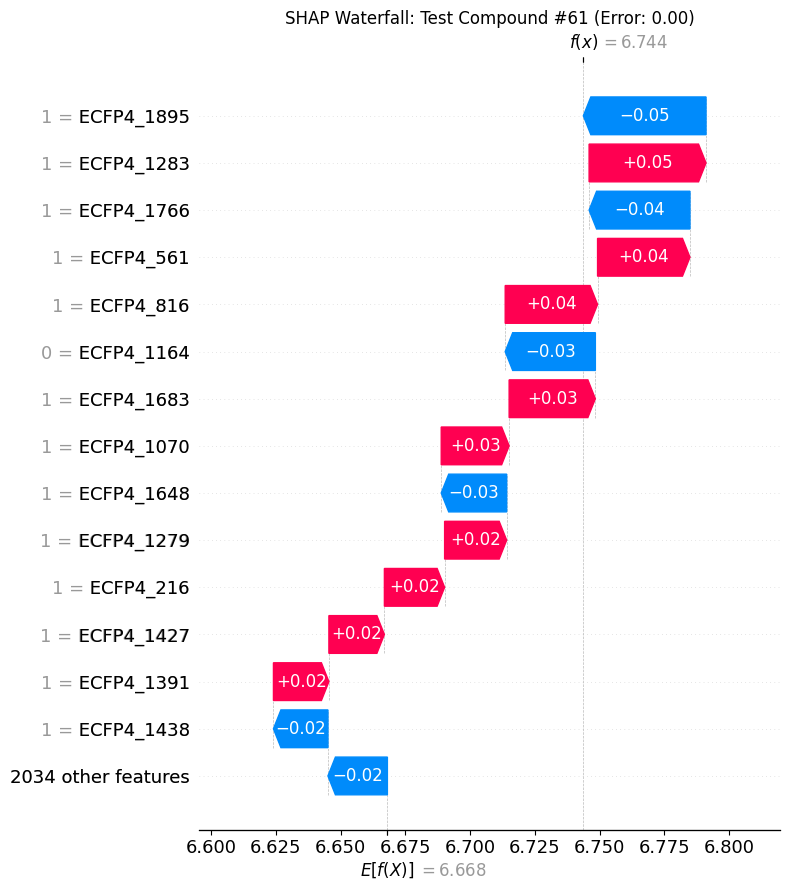

In [ ]:
# SHAP waterfall plot for individual prediction
plt.figure(figsize=(12, 6))

# Select a compound with good prediction accuracy
errors = np.abs(y_pred_test - y_test)
good_pred_idx = np.argmin(errors)

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values_test[good_pred_idx],
        base_values=explainer.expected_value,
        data=X_test[good_pred_idx],
        feature_names=feature_cols
    ),
    max_display=15,
    show=False
)

plt.title(f'SHAP Waterfall: Test Compound #{good_pred_idx} (Error: {errors[good_pred_idx]:.2f})', fontsize=12)
plt.tight_layout()
plt.show()


##6.5 Saving Interpretation Results

In [ ]:
import os
import shutil
from google.colab import files

# Create interpretation directory
os.makedirs('interpretation', exist_ok=True)

# Save feature importance
feature_importance_df.to_csv('interpretation/DATASET_shap_feature_importance.csv', index=False)

# Save test predictions
pred_df = pd.DataFrame({
    'smiles': test_smiles,
    'y_true': y_test,
    'y_pred': y_pred_test,
})
pred_df.to_csv('interpretation/DATASET_test_predictions.csv', index=False)

# Save SHAP values
np.save('interpretation/DATASET_shap_values_test.npy', shap_values_test)

# Auto-download all files
download_files = [
    'shap_summary_plot.png',
]

for f in download_files:
    if os.path.exists(f):
        files.download(f)
        print(f"Downloaded: {f}")
    else:
        print(f"Not found: {f}")

shutil.make_archive('interpretation', 'zip', '.', 'interpretation')
files.download('interpretation.zip')

print("Downloaded: interpretation.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: shap_summary_plot.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: interpretation.zip


In [ ]:
import shutil
shutil.make_archive('models', 'zip', 'models')
files.download('models.zip')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Part 7: Model Deployment

##7.1 Loading or Uploading the Model

###7.1.1 Load Model

In [66]:
import joblib
from sklearn.ensemble import RandomForestRegressor
from google.colab import files

def upload_model():
    """
    Upload a pre-trained Random Forest ECFP4 model.
    Expected format: joblib file containing sklearn RandomForestRegressor
    """
    print("Please upload your model file (.joblib format):")
    print("Expected: RandomForestRegressor trained on ECFP4 fingerprints (2048 bits)")
    print()

    uploaded = files.upload()

    if len(uploaded) == 0:
        print("No file uploaded.")
        return None

    # Get the uploaded filename
    filename = list(uploaded.keys())[0]
    print(f"\nUploaded: {filename}")

    # Load and validate the model
    try:
        model = joblib.load(filename)

        # Validate it's a RandomForestRegressor
        if not isinstance(model, RandomForestRegressor):
            print(f"[ERROR] Expected RandomForestRegressor, got {type(model).__name__}")
            return None

        print(f"\n[SUCCESS] Model loaded successfully!")
        print(f"  Type: {type(model).__name__}")
        print(f"  Number of estimators: {model.n_estimators}")
        print(f"  Number of features: {model.n_features_in_}")

        # Validate feature count matches ECFP4 (2048 bits)
        if model.n_features_in_ != 2048:
            print(f"\n[WARNING] Model expects {model.n_features_in_} features.")
            print(f"          Standard ECFP4 has 2048 bits.")
            print(f"          Ensure your model was trained on the same fingerprint settings.")

        return model

    except Exception as e:
        print(f"[ERROR] Failed to load model: {e}")
        return None

# Upload and load model
model = upload_model()


Please upload your model file (.joblib format):
Expected: RandomForestRegressor trained on ECFP4 fingerprints (2048 bits)



Saving rf_optimized_fingerprints.joblib to rf_optimized_fingerprints.joblib

Uploaded: rf_optimized_fingerprints.joblib

[SUCCESS] Model loaded successfully!
  Type: RandomForestRegressor
  Number of estimators: 200
  Number of features: 2048


###7.1.2 Loading Training Data for Applicability Domain

In [69]:
# Load training fingerprints for AD assessment
import pandas as pd

def load_training_fingerprints():
    """Load training fingerprints for Applicability Domain assessment."""

    # Try to detect environment and use appropriate upload method
    try:
        # Google Colab
        from google.colab import files
        print("Please upload your ECFP4 training fingerprints CSV file:")
        uploaded = files.upload()

        if uploaded:
            filename = list(uploaded.keys())[0]
            train_fp = pd.read_csv(filename)
        else:
            print("No file uploaded. AD assessment will be disabled.")
            return None, False

    except ImportError:
        # Local environment - prompt for file path
        filepath = input("Enter the path to your ECFP4 training fingerprints CSV file: ").strip()

        if not filepath:
            print("No file path provided. AD assessment will be disabled.")
            return None, False

        try:
            train_fp = pd.read_csv(filepath)
        except FileNotFoundError:
            print(f"File not found: {filepath}")
            print("AD assessment will be disabled.")
            return None, False

    # Process the loaded dataframe
    metadata_cols = ['molecule_chembl_id', 'smiles', 'pIC50']
    feature_cols = [c for c in train_fp.columns if c not in metadata_cols]
    X_train_ref = train_fp[feature_cols].values
    print(f"Loaded training fingerprints for AD: {X_train_ref.shape}")

    return X_train_ref, True

# Run the function
X_train_ref, TRAIN_DATA_LOADED = load_training_fingerprints()


Please upload your ECFP4 training fingerprints CSV file:


Saving DATASET_ecfp4_train.csv to DATASET_ecfp4_train (1).csv
Loaded training fingerprints for AD: (635, 2048)


##7.2 Complete Prediction Pipeline

###7.2.1 Structure Standardization

In [70]:
!pip install rdkit -q

import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.MolStandardize import rdMolStandardize

def standardize_smiles(smiles):
    """
    Standardize a SMILES string for consistent fingerprint generation.

    Steps:
    1. Parse SMILES
    2. Remove salts and counterions
    3. Neutralize charges where possible
    4. Generate canonical SMILES

    Returns: (standardized_smiles, error_message)
    """
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None, "Invalid SMILES"

        # Remove salts
        remover = rdMolStandardize.FragmentRemover()
        mol = remover.remove(mol)

        # Neutralize
        uncharger = rdMolStandardize.Uncharger()
        mol = uncharger.uncharge(mol)

        # Generate canonical SMILES
        std_smiles = Chem.MolToSmiles(mol, canonical=True)

        return std_smiles, None

    except Exception as e:
        return None, str(e)


###7.2.2 Fingerprint Generation

In [71]:
from rdkit.Chem import rdFingerprintGenerator

def generate_ecfp4(smiles, radius=2, n_bits=2048):
    """
    Generate ECFP4 fingerprint from SMILES.

    Parameters:
    - smiles: Input SMILES string
    - radius: Morgan fingerprint radius (2 for ECFP4)
    - n_bits: Fingerprint length (2048 standard)

    Returns: (fingerprint_array, error_message)
    """
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None, "Invalid SMILES"

        morgan_gen = rdFingerprintGenerator.GetMorganGenerator(
            radius=radius, fpSize=n_bits
        )
        fp_array = morgan_gen.GetFingerprintAsNumPy(mol)

        return fp_array, None

    except Exception as e:
        return None, str(e)


###7.2.3 Applicability Domain Assessment

In [72]:
def calculate_tanimoto_similarity(fp1, fp_matrix):
    """
    Calculate Tanimoto similarity between a fingerprint and a matrix of fingerprints.
    """
    intersection = fp1 @ fp_matrix.T
    sum_fp1 = fp1.sum()
    sum_fp_matrix = fp_matrix.sum(axis=1)
    union = sum_fp1 + sum_fp_matrix - intersection

    similarity = np.divide(
        intersection, union,
        out=np.zeros_like(intersection, dtype=float),
        where=union != 0
    )

    return similarity

def assess_applicability_domain(fp, X_train_ref, k=5, threshold=0.3):
    """
    Assess if a compound is within the applicability domain.

    Returns: (inside_ad, knn_similarity, nearest_neighbor_sim)
    """
    if X_train_ref is None:
        return None, None, None

    similarities = calculate_tanimoto_similarity(fp, X_train_ref)

    # Get k nearest neighbors
    top_k_sims = np.sort(similarities)[-k:]
    knn_similarity = top_k_sims.mean()
    nearest_neighbor_sim = similarities.max()

    inside_ad = knn_similarity >= threshold

    return inside_ad, knn_similarity, nearest_neighbor_sim


###7.2.4 Main Prediction Class


In [73]:
class BRD2Predictor:
    """
    Complete prediction pipeline for BRD2 pIC50 prediction.
    """

    def __init__(self, model, X_train_ref=None, ad_threshold=0.3, ad_k=5):
        self.model = model
        self.X_train_ref = X_train_ref
        self.ad_threshold = ad_threshold
        self.ad_k = ad_k

        print("BRD2Predictor initialized:")
        print(f"  Model: RandomForest with {model.n_estimators} trees")
        print(f"  AD enabled: {X_train_ref is not None}")
        if X_train_ref is not None:
            print(f"  AD threshold: {ad_threshold}")
            print(f"  AD k-neighbors: {ad_k}")

    def predict_single(self, smiles, compound_name='Unknown'):
        """Predict for a single compound."""
        result = {
            'compound_name': compound_name,
            'input_smiles': smiles,
            'standardized_smiles': None,
            'valid': False,
            'error': None,
            'pIC50_pred': None,
            'inside_ad': None,
            'knn_similarity': None,
            'nn_similarity': None,
            'reliability': None,
            'fingerprint': None
        }

        # Standardize
        std_smiles, error = standardize_smiles(smiles)
        if error:
            result['error'] = f'Standardization failed: {error}'
            return result
        result['standardized_smiles'] = std_smiles

        # Generate fingerprint
        fp, error = generate_ecfp4(std_smiles)
        if error:
            result['error'] = f'Fingerprint failed: {error}'
            return result
        result['fingerprint'] = fp
        result['valid'] = True

        # Predict
        fp_2d = fp.reshape(1, -1)
        result['pIC50_pred'] = self.model.predict(fp_2d)[0]

        # AD assessment
        inside_ad, knn_sim, nn_sim = assess_applicability_domain(
            fp, self.X_train_ref, self.ad_k, self.ad_threshold
        )
        result['inside_ad'] = inside_ad
        result['knn_similarity'] = knn_sim
        result['nn_similarity'] = nn_sim

        # Reliability classification
        if inside_ad is None:
            result['reliability'] = 'Unknown (no AD)'
        elif inside_ad:
            result['reliability'] = 'High'
        else:
            result['reliability'] = 'Low'

        return result

    def predict_batch(self, df, smiles_col='SMILES', name_col='compound_name'):
        """
        Predict for a batch of compounds from a DataFrame.
        """
        results = []
        n_total = len(df)

        print(f"Processing {n_total} compounds...")

        for i, row in df.iterrows():
            smiles = row[smiles_col]
            name = row.get(name_col, f'Compound_{i}')

            result = self.predict_single(smiles, name)
            results.append(result)

            if (i + 1) % 100 == 0:
                print(f"  Processed {i + 1}/{n_total}...")

        # Convert to DataFrame
        results_df = pd.DataFrame(results)

        # Add fingerprint columns
        fp_cols = [f'ECFP4_{i}' for i in range(2048)]
        fp_matrix = np.vstack([
            r['fingerprint'] if r['fingerprint'] is not None else np.zeros(2048)
            for r in results
        ])
        fp_df = pd.DataFrame(fp_matrix, columns=fp_cols)

        # Combine (without duplicate fingerprint column)
        results_df = results_df.drop(columns=['fingerprint'])
        results_df = pd.concat([results_df, fp_df], axis=1)

        # Summary
        n_valid = results_df['valid'].sum()
        n_inside_ad = results_df['inside_ad'].sum() if self.X_train_ref is not None else 'N/A'

        print(f"\nPrediction complete:")
        print(f"  Valid compounds: {n_valid}/{n_total}")
        print(f"  Inside AD: {n_inside_ad}")

        return results_df


##7.3 Running the Prediction Pipeline

###7.3.1 Upload Input File

In [74]:
from google.colab import files

def upload_input_csv():
    """Upload input CSV file for prediction."""
    print("Please upload your input CSV file:")
    print("Required columns: SMILES, compound_name")
    print()

    uploaded = files.upload()

    if len(uploaded) == 0:
        print("No file uploaded.")
        return None

    filename = list(uploaded.keys())[0]
    print(f"\nUploaded: {filename}")

    # Load and validate
    df = pd.read_csv(filename)
    print(f"Loaded {len(df)} compounds")
    print(f"Columns: {list(df.columns)}")

    # Check required columns
    if 'SMILES' not in df.columns:
        print("[ERROR] Missing required column: SMILES")
        return None

    if 'compound_name' not in df.columns:
        print("[WARNING] Missing compound_name column. Will use index as name.")
        df['compound_name'] = [f'Compound_{i}' for i in range(len(df))]

    return df

# Upload input file
input_df = upload_input_csv()


Please upload your input CSV file:
Required columns: SMILES, compound_name



Saving BRD4_1M_Top2000.csv to BRD4_1M_Top2000.csv

Uploaded: BRD4_1M_Top2000.csv
Loaded 2000 compounds
Columns: ['tranche', 'zincid', 'SMILES', 'pIC50_pred', 'knn_similarity', 'reliability']
[WARNING] Missing compound_name column. Will use index as name.


###7.3.2 Data Leakage Check

Before running BRD2 predictions, compounds in the BRD4 top-2000
candidate library were checked against the BRD2 training, validation,
and test sets using canonical SMILES matching. Any overlapping compounds
were removed to prevent data leakage and ensure predictions reflect
genuine generalisation performance.

In [75]:
import pandas as pd
from rdkit import Chem
from tqdm import tqdm

tqdm.pandas()

# Build exclusion set from BRD2 train/val/test splits
print("Building exclusion set from BRD2 training data...")

files_to_block = [
    'DATASET_ecfp4_train.csv',
    'DATASET_ecfp4_val.csv',
    'DATASET_ecfp4_test.csv'
]

global_smiles_set = set()

for file in files_to_block:
    try:
        df = pd.read_csv(file)
        for smi in tqdm(df['smiles'], desc=f"Processing {file}"):
            try:
                mol = Chem.MolFromSmiles(smi)
                if mol is not None:
                    global_smiles_set.add(Chem.MolToSmiles(mol, canonical=True))
            except:
                continue
        print(f"  [OK] {file}: {len(df)} compounds added")
    except FileNotFoundError:
        print(f"  [WARNING] File not found: {file}")

print(f"\nExclusion set built: {len(global_smiles_set)} unique compounds")

# Filter input_df against exclusion set
print("\nChecking BRD4 top-2000 against exclusion set...")
keep_indices = []

for idx, row in tqdm(input_df.iterrows(), total=len(input_df), desc="Filtering"):
    smi = row['SMILES']
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            can_smi = Chem.MolToSmiles(mol, canonical=True)
            if can_smi not in global_smiles_set:
                keep_indices.append(idx)
    except:
        pass

input_df_clean = input_df.loc[keep_indices].copy()

print(f"\nData leakage check complete:")
print(f"  Input:    {len(input_df)} compounds")
print(f"  Removed:  {len(input_df) - len(input_df_clean)} overlapping compounds")
print(f"  Retained: {len(input_df_clean)} compounds")

# No overlapping compounds found: input_df_clean == input_df
# Use input_df_clean for all downstream predictions
input_df = input_df_clean

Building exclusion set from BRD2 training data...


Processing DATASET_ecfp4_train.csv: 100%|██████████| 635/635 [00:00<00:00, 1839.80it/s]


  [OK] DATASET_ecfp4_train.csv: 635 compounds added


Processing DATASET_ecfp4_val.csv: 100%|██████████| 82/82 [00:00<00:00, 2033.12it/s]


  [OK] DATASET_ecfp4_val.csv: 82 compounds added


Processing DATASET_ecfp4_test.csv: 100%|██████████| 89/89 [00:00<00:00, 2034.43it/s]


  [OK] DATASET_ecfp4_test.csv: 89 compounds added

Exclusion set built: 806 unique compounds

Checking BRD4 top-2000 against exclusion set...


Filtering: 100%|██████████| 2000/2000 [00:01<00:00, 1884.12it/s]


Data leakage check complete:
  Input:    2000 compounds
  Removed:  0 overlapping compounds
  Retained: 2000 compounds


No overlapping compounds found between BRD4 top-2000 and BRD2 training/val/test sets.
input_df used directly for prediction (equivalent to input_df_clean).

###7.3.3 Initialize Predictor and Run

In [76]:
# Initialize predictor with loaded model and training data
predictor = BRD2Predictor(
    model=model,
    X_train_ref=X_train_ref if TRAIN_DATA_LOADED else None,
    ad_threshold=0.3,
    ad_k=5
)


BRD2Predictor initialized:
  Model: RandomForest with 200 trees
  AD enabled: True
  AD threshold: 0.3
  AD k-neighbors: 5


In [78]:
# input_df already loaded and cleaned above (data leakage check applied)

# Rename BRD4 columns upfront for clarity
input_df = input_df.rename(columns={
    'pIC50_pred':     'brd4_pic50',
    'knn_similarity': 'brd4_knn_similarity',
    'reliability':    'brd4_reliability'
})

print("[OK] BRD4 columns renamed successfully!")
print(f"Columns: {list(input_df.columns)}")

[OK] BRD4 columns renamed successfully!
Columns: ['tranche', 'zincid', 'SMILES', 'brd4_pic50', 'brd4_knn_similarity', 'brd4_reliability', 'compound_name']


In [79]:
# Run BRD2 predictions
results = predictor.predict_batch(input_df, smiles_col='SMILES', name_col='compound_name')

# Rename BRD2 columns immediately
results = results.rename(columns={
    'pIC50_pred':    'brd2_pic50',
    'knn_similarity': 'brd2_knn_similarity',
    'reliability':   'brd2_reliability'
})

Processing 2000 compounds...


[05:16:18] Running FragmentRemover
[05:16:18] Running Uncharger
[05:16:18] Running FragmentRemover
[05:16:18] Running Uncharger
[05:16:19] Running FragmentRemover
[05:16:19] Running Uncharger
[05:16:19] Running FragmentRemover
[05:16:19] Running Uncharger
[05:16:19] Running FragmentRemover
[05:16:19] Running Uncharger
[05:16:20] Running FragmentRemover
[05:16:20] Running Uncharger
[05:16:20] Running FragmentRemover
[05:16:20] Running Uncharger
[05:16:20] Running FragmentRemover
[05:16:20] Running Uncharger
[05:16:21] Running FragmentRemover
[05:16:21] Running Uncharger
[05:16:21] Running FragmentRemover
[05:16:21] Running Uncharger
[05:16:21] Running FragmentRemover
[05:16:21] Running Uncharger
[05:16:22] Running FragmentRemover
[05:16:22] Running Uncharger
[05:16:22] Running FragmentRemover
[05:16:22] Running Uncharger
[05:16:22] Running FragmentRemover
[05:16:22] Running Uncharger
[05:16:22] Running FragmentRemover
[05:16:22] Running Uncharger
[05:16:22] Running FragmentRemover
[05:1

  Processed 100/2000...


[05:16:37] Running FragmentRemover
[05:16:37] Running Uncharger
[05:16:37] Running FragmentRemover
[05:16:37] Running Uncharger
[05:16:37] Running FragmentRemover
[05:16:37] Running Uncharger
[05:16:37] Running FragmentRemover
[05:16:37] Running Uncharger
[05:16:37] Running FragmentRemover
[05:16:37] Running Uncharger
[05:16:37] Running FragmentRemover
[05:16:37] Running Uncharger
[05:16:37] Running FragmentRemover
[05:16:37] Running Uncharger
[05:16:37] Running FragmentRemover
[05:16:37] Running Uncharger
[05:16:38] Running FragmentRemover
[05:16:38] Running Uncharger
[05:16:38] Running FragmentRemover
[05:16:38] Running Uncharger
[05:16:38] Running FragmentRemover
[05:16:38] Running Uncharger
[05:16:38] Running FragmentRemover
[05:16:38] Running Uncharger
[05:16:38] Running FragmentRemover
[05:16:38] Running Uncharger
[05:16:38] Running FragmentRemover
[05:16:38] Running Uncharger
[05:16:38] Running FragmentRemover
[05:16:38] Running Uncharger
[05:16:38] Running FragmentRemover
[05:1

  Processed 200/2000...


...

[05:18:54] Running FragmentRemover
[05:18:54] Running Uncharger
[05:18:54] Running FragmentRemover
[05:18:54] Running Uncharger
[05:18:54] Running FragmentRemover
[05:18:54] Running Uncharger
[05:18:54] Running FragmentRemover
[05:18:54] Running Uncharger
[05:18:54] Running FragmentRemover
[05:18:54] Running Uncharger
[05:18:54] Running FragmentRemover
[05:18:54] Running Uncharger
[05:18:54] Running FragmentRemover
[05:18:54] Running Uncharger
[05:18:54] Running FragmentRemover
[05:18:54] Running Uncharger
[05:18:54] Running FragmentRemover
[05:18:54] Running Uncharger
[05:18:55] Running FragmentRemover
[05:18:55] Running Uncharger
[05:18:55] Running FragmentRemover
[05:18:55] Running Uncharger
[05:18:55] Running FragmentRemover
[05:18:55] Running Uncharger
[05:18:55] Running FragmentRemover
[05:18:55] Running Uncharger
[05:18:55] Running FragmentRemover
[05:18:55] Running Uncharger
[05:18:55] Running FragmentRemover
[05:18:55] Running Uncharger
[05:18:55] Running FragmentRemover
[05:1

  Processed 1900/2000...


[05:19:01] Running FragmentRemover
[05:19:01] Running Uncharger
[05:19:02] Running FragmentRemover
[05:19:02] Running Uncharger
[05:19:02] Running FragmentRemover
[05:19:02] Running Uncharger
[05:19:02] Running FragmentRemover
[05:19:02] Running Uncharger
[05:19:02] Running FragmentRemover
[05:19:02] Running Uncharger
[05:19:02] Running FragmentRemover
[05:19:02] Running Uncharger
[05:19:02] Running FragmentRemover
[05:19:02] Running Uncharger
[05:19:02] Running FragmentRemover
[05:19:02] Running Uncharger
[05:19:02] Running FragmentRemover
[05:19:02] Running Uncharger
[05:19:02] Running FragmentRemover
[05:19:02] Running Uncharger
[05:19:02] Running FragmentRemover
[05:19:02] Running Uncharger
[05:19:02] Running FragmentRemover
[05:19:02] Running Uncharger
[05:19:02] Running FragmentRemover
[05:19:02] Running Uncharger
[05:19:02] Running FragmentRemover
[05:19:02] Running Uncharger
[05:19:03] Running FragmentRemover
[05:19:03] Running Uncharger
[05:19:03] Running FragmentRemover
[05:1

  Processed 2000/2000...

Prediction complete:
  Valid compounds: 2000/2000
  Inside AD: 8


[05:19:09] Running FragmentRemover
[05:19:09] Running Uncharger
[05:19:09] Running FragmentRemover
[05:19:09] Running Uncharger


In [80]:
# Step 1: Extract BRD2 results and merge with BRD4 table
df_brd2 = results[['input_smiles', 'brd2_pic50', 'brd2_knn_similarity', 'brd2_reliability']].copy()
final_table = input_df.merge(df_brd2, left_on='SMILES', right_on='input_smiles', how='left')

# Drop the redundant input_smiles column after merging
final_table = final_table.drop(columns=['input_smiles'])

# Step 2: Calculate selectivity delta (BRD4 - BRD2)
final_table['delta_pic50'] = final_table['brd4_pic50'] - final_table['brd2_pic50']

# Step 3: Sort by delta descending (most selective compounds first)
final_table = final_table.sort_values(by='delta_pic50', ascending=False)

print("✅ Merge complete! Final table preview:")
print(final_table[['zincid', 'brd4_pic50', 'brd2_pic50', 'delta_pic50']].head(10))

final_table.to_csv('Final_Selective_Hits_Optimized.csv', index=False)

✅ Merge complete! Final table preview:
                zincid  brd4_pic50  brd2_pic50  delta_pic50
3     ZINCmb000003WlMF    6.669846    5.864572     0.805274
0     ZINCot00000lftZp    6.761894    5.995006     0.766888
295   ZINCpg000027YJ6X    6.388412    5.636875     0.751538
1     ZINCns000000OqwT    6.708138    6.022393     0.685745
796   ZINCpf000015NlNC    6.325026    5.654908     0.670118
1073  ZINCnr00000otWJb    6.303305    5.648379     0.654926
13    ZINCoe00000HOhHN    6.566732    5.914579     0.652153
1163  ZINCp500000hWUDh    6.297822    5.648626     0.649195
5     ZINCpz00000vKa04    6.637285    5.989480     0.647805
160   ZINCn500001P1fpy    6.424816    5.782701     0.642115


In [82]:
from google.colab import files
files.download('Final_Selective_Hits_Optimized.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##7.4 Output Formats and Export

Final selectivity scores saved to `Final_Selective_Hits_Optimized.csv`.
Ligand 3D preparation for docking was performed using a separate pipeline,
taking `BRD4_1M_Top2000.csv` as input.